# Exathlon Benchmark — Exploration & Visualization

## Dataset Overview

The **Exathlon Benchmark** is a dataset for **explainable anomaly detection** in high-dimensional time series, collected from 10 Apache Spark streaming applications running on a cluster. It captures real performance metrics during normal operation and under various anomaly-inducing conditions.

### Key Characteristics
| Property | Value |
|---|---|
| **Source** | Apache Spark streaming applications (real cluster data) |
| **Total Samples** | ~47,530 per trace |
| **Dimensions** | 2,283 performance metrics |
| **Entities** | 10 different Spark applications (app1–app10) |
| **Anomaly Types** | Bursty input, bursty input with stalled, CPU contention, etc. |
| **Labels** | Segment-level ground truth with anomaly type + root cause timing |

### Research Relevance for Industry 5.0
- **Anomaly Detection**: Multiple anomaly types with root cause annotations — ideal for explainable AD
- **Clustering**: 10 applications with different workloads — natural clustering by application type
- **Predictive Maintenance**: Anomalies represent real system degradation in cloud/edge infrastructure
- **High Dimensionality**: 2,283 features challenge scalability of MTS methods


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

EXATHLON_DIR = 'exathlon'
RAW_DIR = os.path.join(EXATHLON_DIR, 'data', 'raw')

# Load ground truth
gt = pd.read_csv('exathlon/data/raw/ground_truth.csv')
print("=== Exathlon Ground Truth ===")
print(f"Shape: {gt.shape}")
print(f"Columns: {list(gt.columns)}")
print(f"\nAnomaly types: {gt['anomaly_type'].unique()}")
print(f"\nTraces per anomaly type:")
print(gt['anomaly_type'].value_counts())


=== Exathlon Ground Truth ===
Shape: (109, 7)
Columns: ['trace_name', 'trace_type', 'anomaly_type', 'anomaly_details', 'root_cause_start', 'root_cause_end', 'extended_effect_end']

Anomaly types: <StringArray>
[      'bursty_input', 'bursty_input_crash',     'cpu_contention',
     'driver_failure',   'executor_failure',      'stalled_input',
            'unknown']
Length: 7, dtype: str

Traces per anomaly type:
anomaly_type
bursty_input          29
cpu_contention        26
stalled_input         16
unknown               12
executor_failure      10
driver_failure         9
bursty_input_crash     7
Name: count, dtype: int64


In [2]:
# List available applications and traces
apps = sorted([d for d in os.listdir(RAW_DIR) if d.startswith('app')])
print(f"Applications: {apps}")
print(f"\nTraces per application:")
for app in apps:
    app_dir = os.path.join(RAW_DIR, app)
    traces = [f for f in os.listdir(app_dir) if f.endswith('.zip')]
    print(f"  {app}: {len(traces)} traces")
    for t in sorted(traces)[:3]:
        # Parse trace name: appid_type_param_traceid
        parts = t.replace('.zip', '').split('_')
        trace_type = 'normal' if parts[1] == '0' else 'anomalous'
        print(f"    {t} ({trace_type})")
    if len(traces) > 3:
        print(f"    ... and {len(traces)-3} more")


Applications: ['app1', 'app10', 'app2', 'app3', 'app4', 'app5', 'app6', 'app7', 'app8', 'app9']

Traces per application:
  app1: 9 traces
    1_0_1000000_14.zip (normal)
    1_0_100000_15.zip (normal)
    1_0_100000_16.zip (normal)
    ... and 6 more
  app10: 1 traces
    10_0_100000_11.zip (normal)
  app2: 1 traces
    2_0_100000_22.zip (normal)
  app3: 1 traces
    3_0_100000_25.zip (normal)
  app4: 1 traces
    4_0_1000000_31.zip (normal)
  app5: 1 traces
    5_0_50000_39.zip (normal)
  app6: 1 traces
    6_0_50000_48.zip (normal)
  app7: 1 traces
    7_0_50000_58.zip (normal)
  app8: 0 traces
  app9: 1 traces
    9_0_100000_3.zip (normal)


In [3]:
# Load a sample trace from app1
def load_trace(app, trace_file):
    zip_path = os.path.join(RAW_DIR, app, trace_file)
    csv_name = trace_file.replace('.zip', '.csv')
    with zipfile.ZipFile(zip_path, 'r') as z:
        with z.open(csv_name) as f:
            df = pd.read_csv(f)
    return df

# Load a normal trace and an anomalous trace from app1
app1_traces = sorted(os.listdir(os.path.join(RAW_DIR, 'app1')))
normal_traces = [t for t in app1_traces if t.endswith('.zip') and '_0_' in t]
anomalous_traces = [t for t in app1_traces if t.endswith('.zip') and '_0_' not in t]

print(f"App1 normal traces: {normal_traces}")
print(f"App1 anomalous traces: {anomalous_traces}")

# Load one of each
if normal_traces:
    normal_df = load_trace('app1', normal_traces[0])
    print(f"\nNormal trace shape: {normal_df.shape}")
    print(f"Columns: {normal_df.shape[1]} (first 5: {list(normal_df.columns[:5])})")
    print(f"Time range: {normal_df['t'].min()} to {normal_df['t'].max()}")
    
if anomalous_traces:
    anomalous_df = load_trace('app1', anomalous_traces[0])
    print(f"\nAnomalous trace shape: {anomalous_df.shape}")


App1 normal traces: ['1_0_1000000_14.zip', '1_0_100000_15.zip', '1_0_100000_16.zip', '1_0_10000_17.zip', '1_0_500000_18.zip', '1_0_500000_19.zip']
App1 anomalous traces: ['1_2_100000_68.zip', '1_4_1000000_80.zip', '1_5_1000000_86.zip']



Normal trace shape: (14347, 2284)
Columns: 2284 (first 5: ['t', '1_CodeGenerator_compilationTime_count', '1_CodeGenerator_compilationTime_max', '1_CodeGenerator_compilationTime_mean', '1_CodeGenerator_compilationTime_min'])
Time range: 1525727288 to 1525741679



Anomalous trace shape: (2936, 2284)


## 1. High-Dimensional Time Series Overview

Exathlon has **2,283 dimensions** — one of the highest-dimensional MTS anomaly detection benchmarks. Below we visualize a selection of key metrics to understand the temporal structure.


Total features: 2265
Non-trivial features (varying, mostly non-missing): 1620


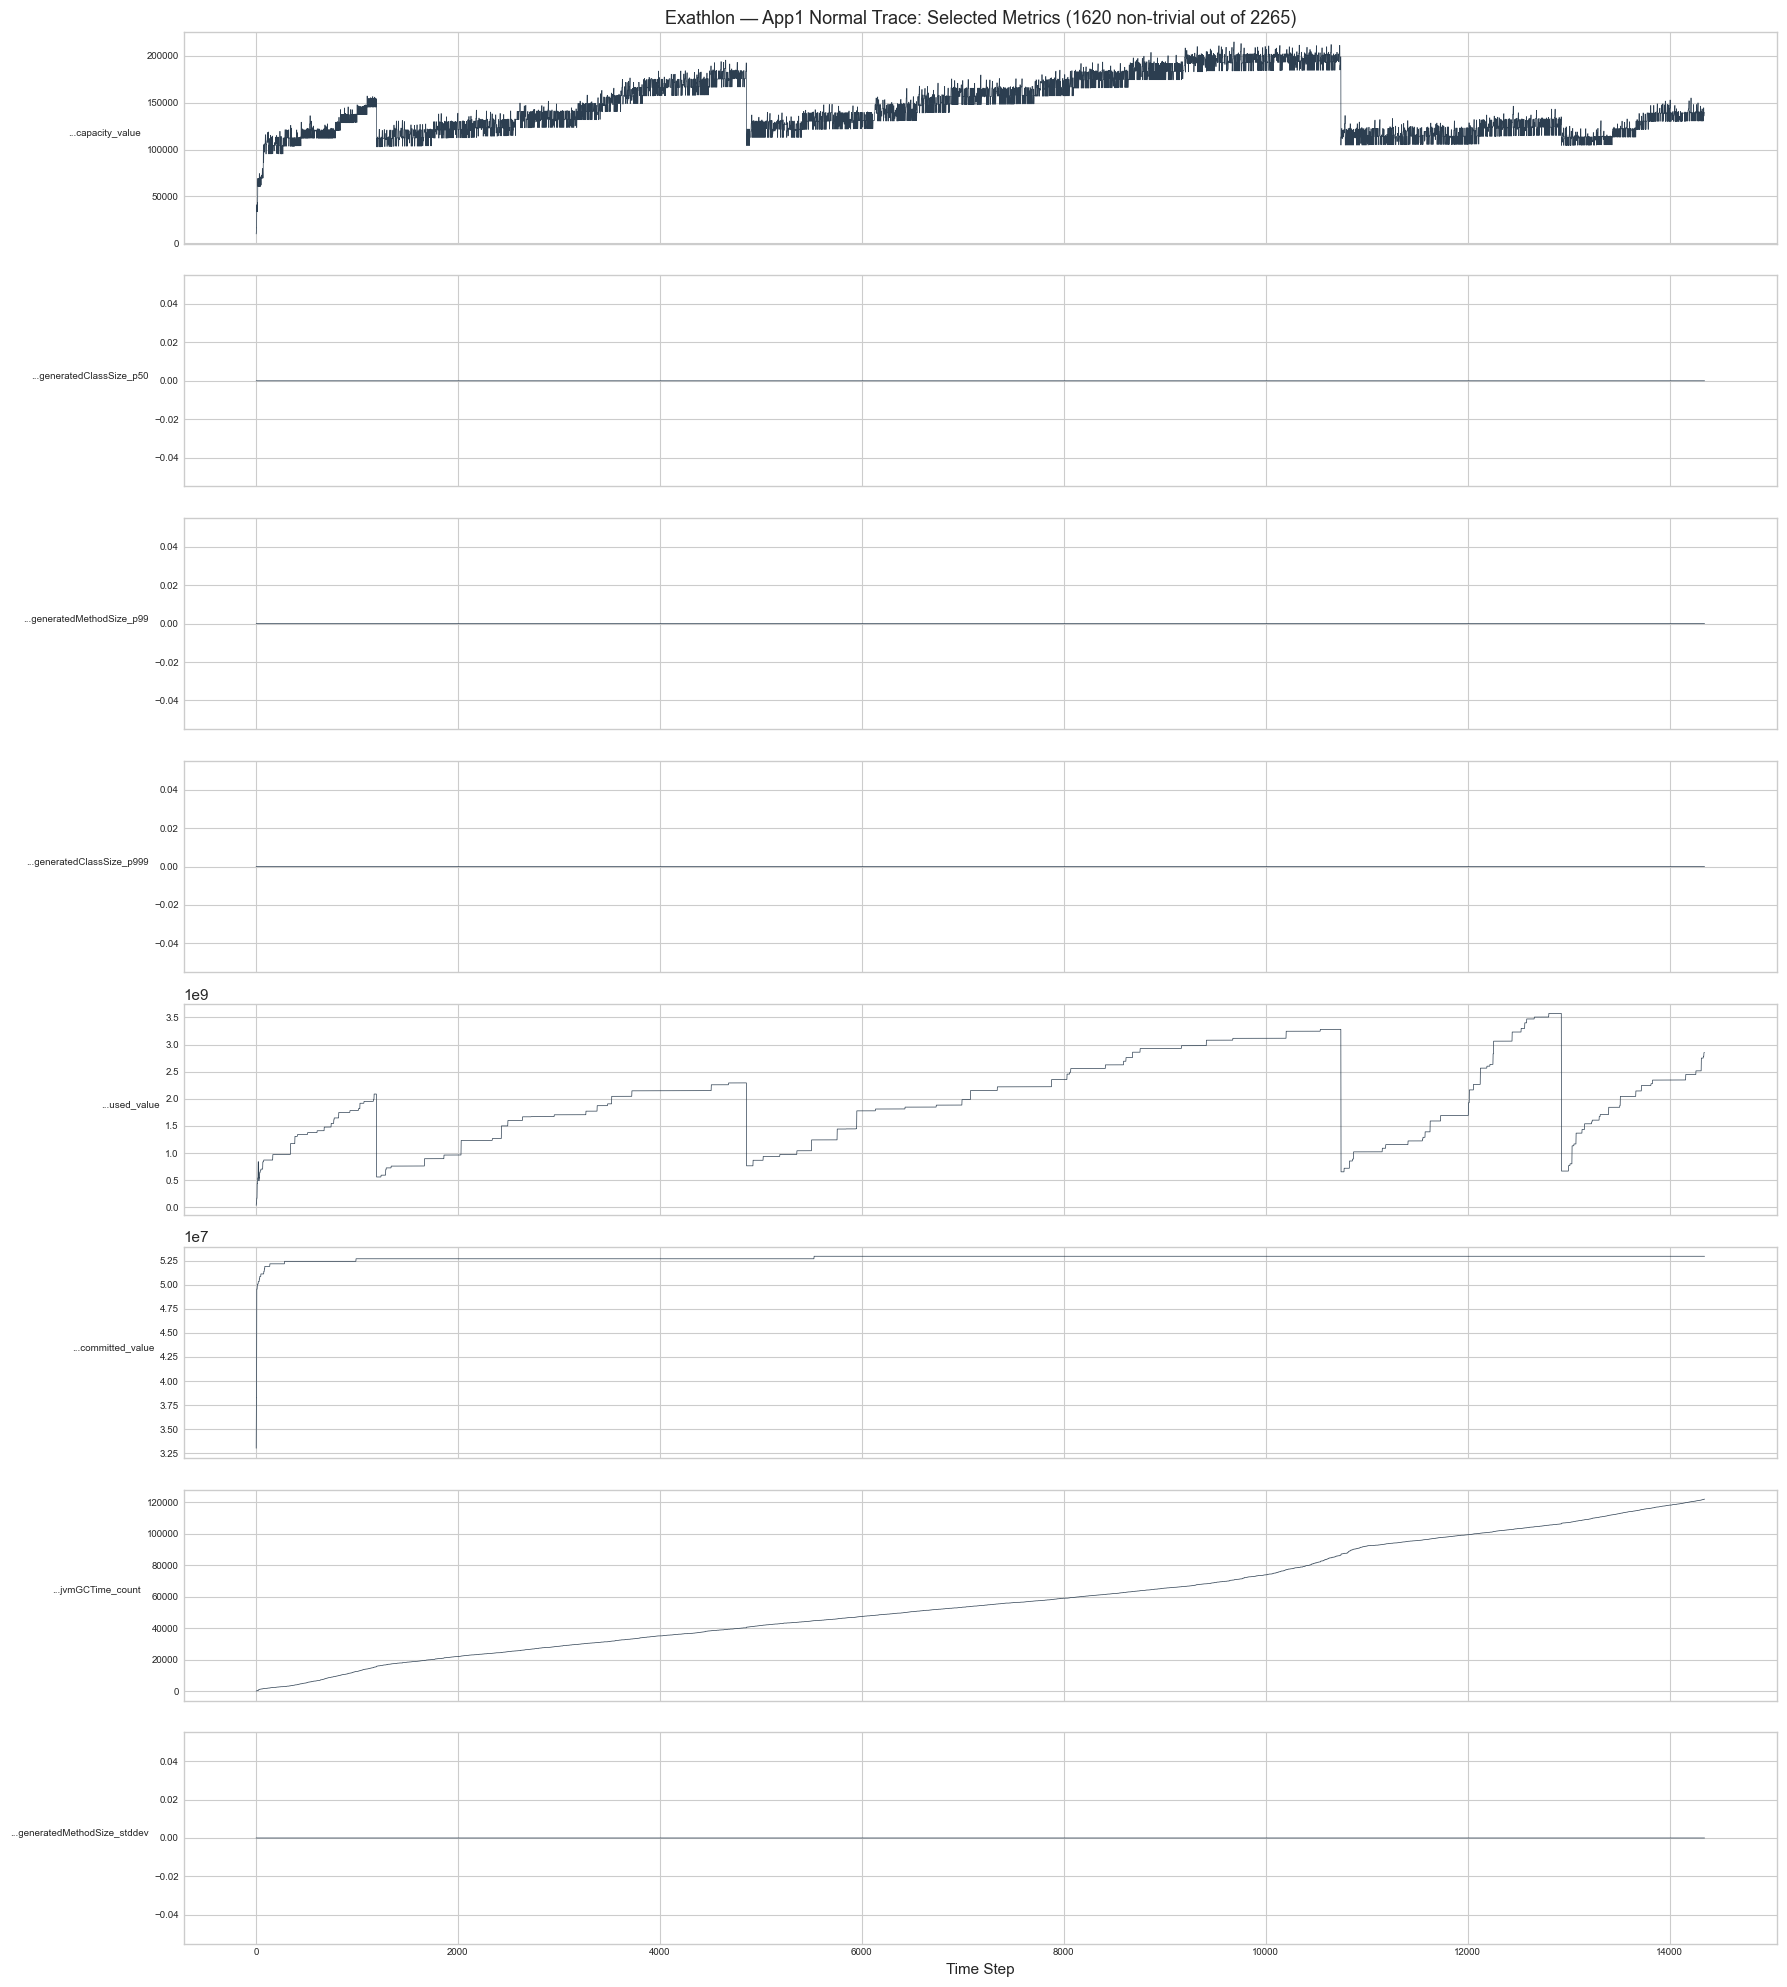

In [4]:
# Visualize selected metrics from the normal trace
if normal_traces:
    df = normal_df.copy()
    
    # Filter out columns that are all -1 (missing) or all constant
    feature_cols = [c for c in df.columns if c != 't']
    # Also define common feature cols for later use with anomalous traces
    if anomalous_traces:
        common_all = sorted(list(set(df.columns) & set(anomalous_df.columns)))
        feature_cols = [c for c in common_all if c != 't']
    non_trivial = []
    for c in feature_cols:
        vals = df[c].values
        if vals.std() > 0 and (vals != -1).mean() > 0.5:
            non_trivial.append(c)
    
    print(f"Total features: {len(feature_cols)}")
    print(f"Non-trivial features (varying, mostly non-missing): {len(non_trivial)}")
    
    # Select 8 representative features
    np.random.seed(42)
    selected = np.random.choice(non_trivial[:200], size=min(8, len(non_trivial)), replace=False)
    
    fig, axes = plt.subplots(len(selected), 1, figsize=(18, 2.5 * len(selected)), sharex=True)
    
    for i, col in enumerate(selected):
        ax = axes[i]
        vals = df[col].values.copy()
        vals[vals == -1] = np.nan  # Replace -1 with NaN
        ax.plot(range(len(vals)), vals, linewidth=0.5, color='#2c3e50')
        short_name = col.split('_')
        ax.set_ylabel(f'...{"_".join(short_name[-2:])}', fontsize=7, rotation=0, ha='right')
        ax.tick_params(labelsize=7)
    
    axes[-1].set_xlabel('Time Step')
    axes[0].set_title(f'Exathlon — App1 Normal Trace: Selected Metrics ({len(non_trivial)} non-trivial out of {len(feature_cols)})', fontsize=13)
    plt.tight_layout()
    plt.show()


## 2. Normal vs Anomalous Trace Comparison

Comparing the same metrics between a normal trace and an anomalous trace reveals how anomalies manifest in the high-dimensional space.


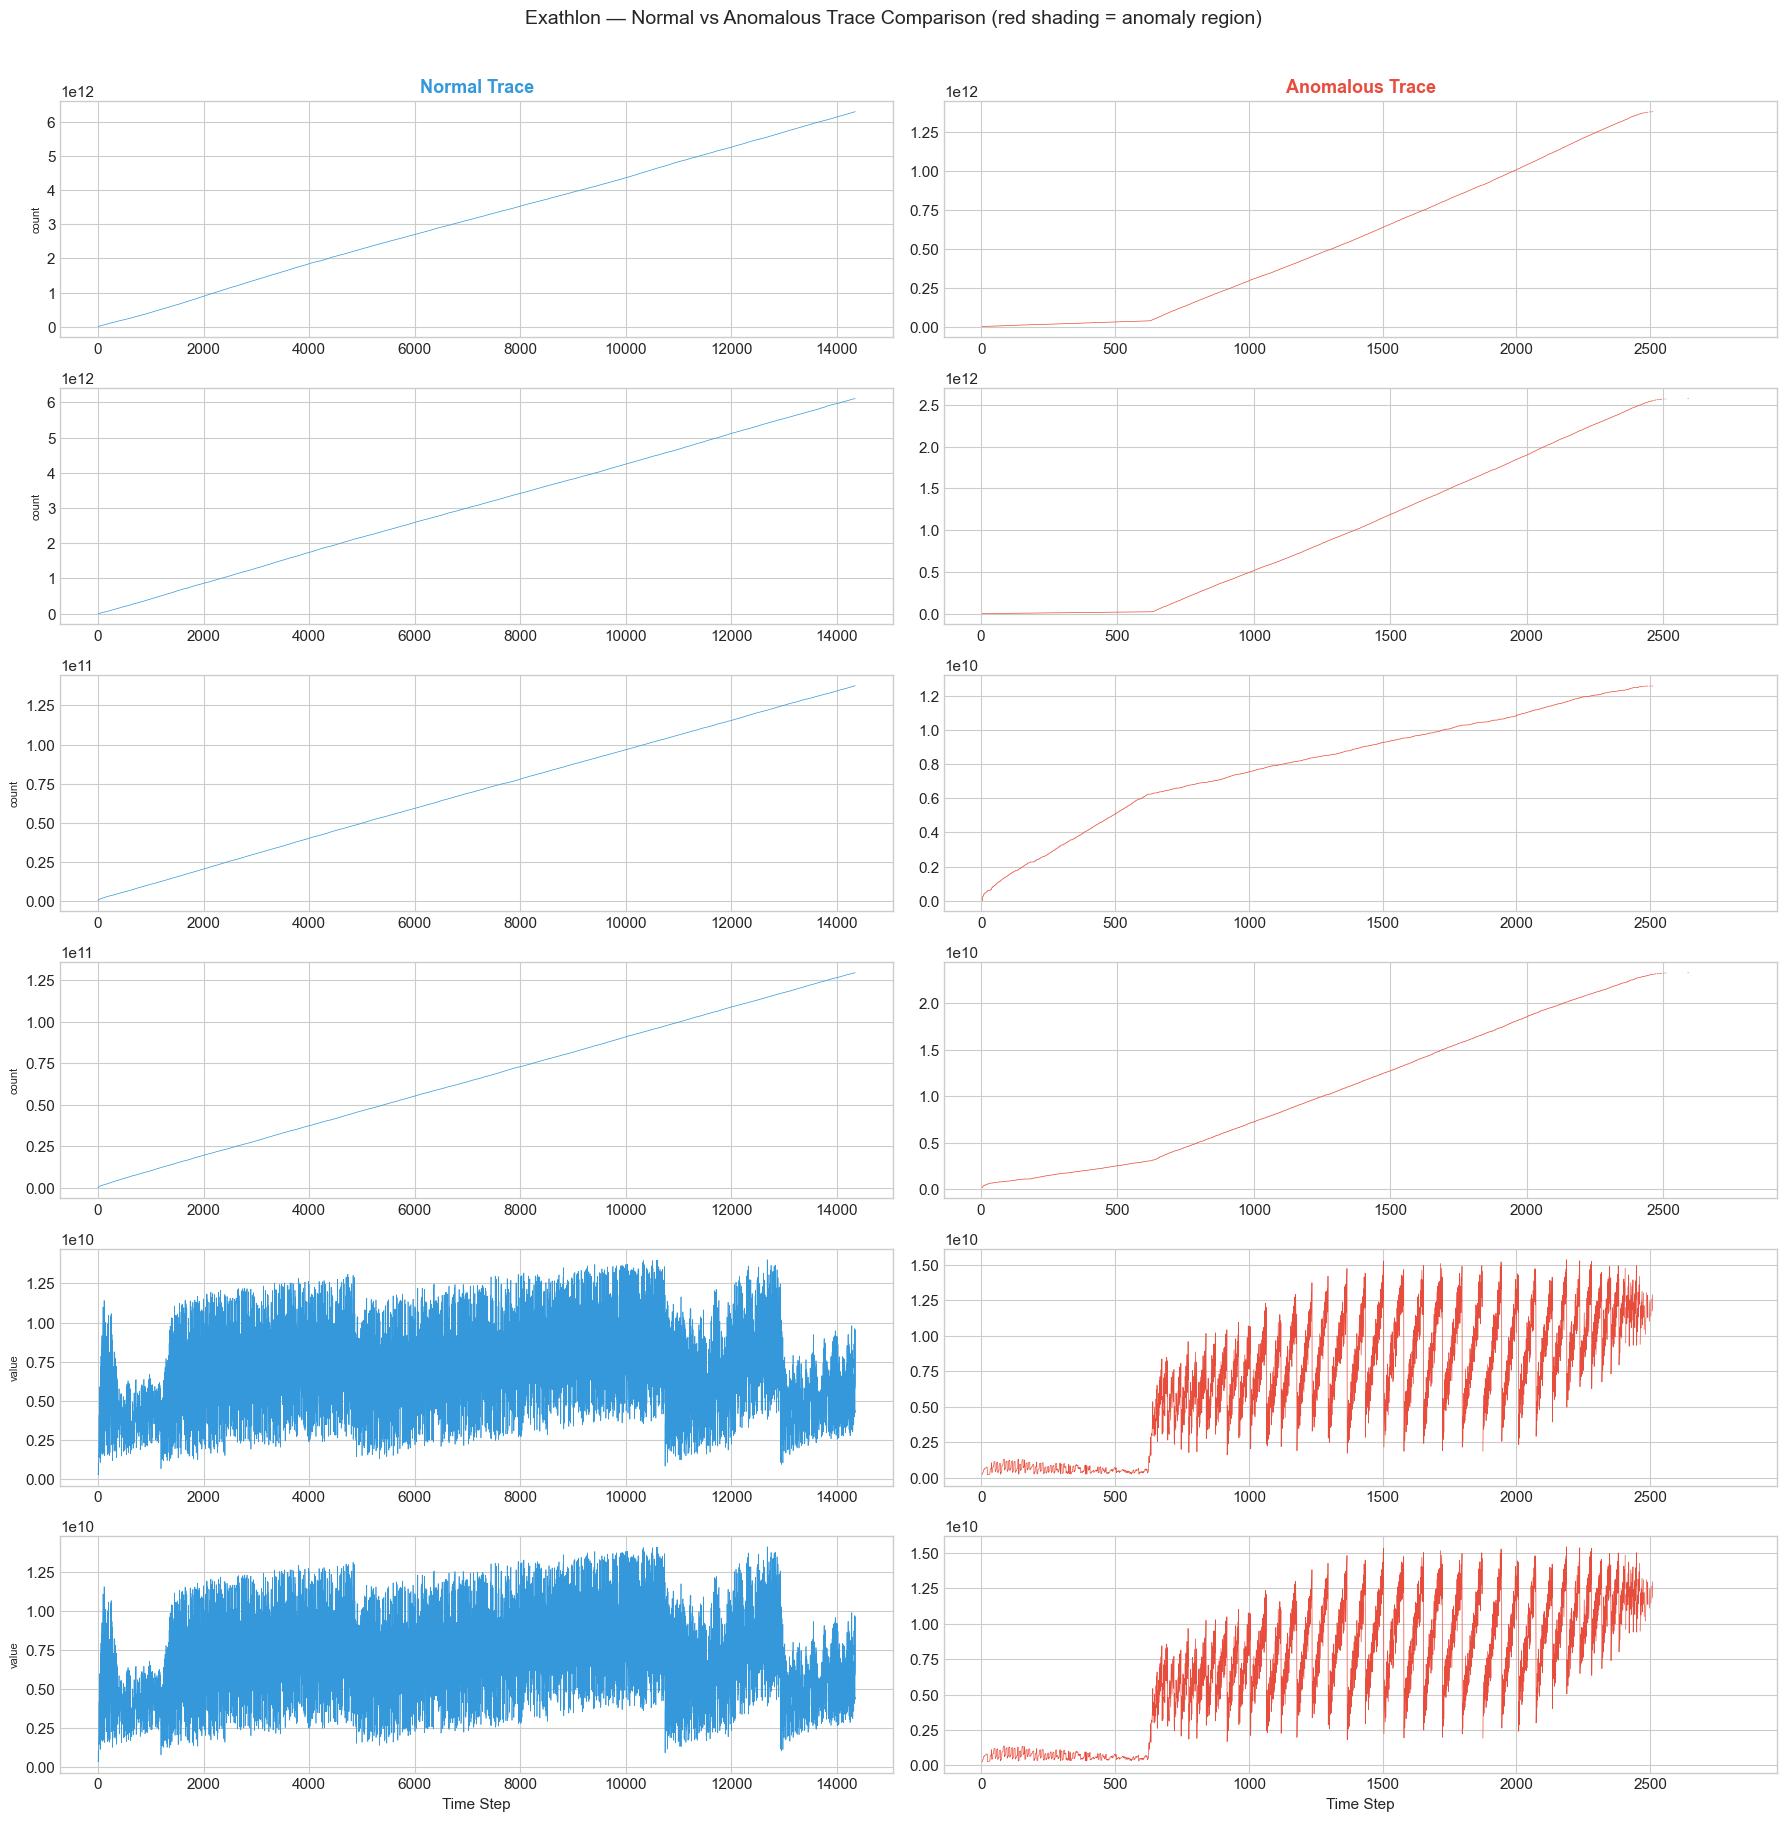

In [5]:
if normal_traces and anomalous_traces:
    # Find common columns between normal and anomalous traces
    common_columns = sorted(list(set(normal_df.columns) & set(anomalous_df.columns)))
    common_feature_cols = [c for c in common_columns if c != 't']
    
    # Find common non-trivial features
    normal_non_trivial = set()
    for c in common_feature_cols:
        vals = normal_df[c].values
        if vals.std() > 0 and (vals != -1).mean() > 0.5:
            normal_non_trivial.add(c)
    
    anom_non_trivial = set()
    for c in common_feature_cols:
        vals = anomalous_df[c].values
        if vals.std() > 0 and (vals != -1).mean() > 0.5:
            anom_non_trivial.add(c)
    
    # Pick the 6 features with highest variance (not just any non-trivial ones)
    common_candidates = list(normal_non_trivial & anom_non_trivial)
    variances = {}
    for c in common_candidates:
        vals = normal_df[c].values.copy().astype(float)
        vals[vals == -1] = np.nan
        v = np.nanvar(vals)
        if v > 0:
            variances[c] = v
    common = sorted(variances, key=variances.get, reverse=True)[:6]
    
    fig, axes = plt.subplots(len(common), 2, figsize=(18, 3 * len(common)))
    
    for i, col in enumerate(common):
        # Normal
        vals_n = normal_df[col].values.copy()
        vals_n[vals_n == -1] = np.nan
        axes[i][0].plot(vals_n, linewidth=0.5, color='#3498db')
        axes[i][0].set_ylabel(col.split('_')[-1][:15], fontsize=8)
        if i == 0:
            axes[i][0].set_title('Normal Trace', fontsize=13, fontweight='bold', color='#3498db')
        
        # Anomalous
        vals_a = anomalous_df[col].values.copy()
        vals_a[vals_a == -1] = np.nan
        axes[i][1].plot(vals_a, linewidth=0.5, color='#e74c3c')
        if i == 0:
            axes[i][1].set_title('Anomalous Trace', fontsize=13, fontweight='bold', color='#e74c3c')
        
        # Highlight anomaly regions from ground truth
        trace_name = anomalous_traces[0].replace('.zip', '')
        trace_gt = gt[gt['trace_name'] == trace_name]
        if len(trace_gt) > 0:
            t_start = anomalous_df['t'].min()
            for _, row in trace_gt.iterrows():
                rc_start = int((row['root_cause_start'] - t_start))
                rc_end = int((row['root_cause_end'] - t_start))
                if rc_start >= 0 and rc_end < len(anomalous_df):
                    axes[i][1].axvspan(rc_start, rc_end, alpha=0.2, color='#e74c3c')
    
    axes[-1][0].set_xlabel('Time Step')
    axes[-1][1].set_xlabel('Time Step')
    plt.suptitle('Exathlon — Normal vs Anomalous Trace Comparison (red shading = anomaly region)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


## 3. Ground Truth Analysis — Anomaly Types and Distribution

The Exathlon ground truth provides rich annotations including anomaly type, root cause timing, and extended effect periods. This enables research on **explainable anomaly detection**.


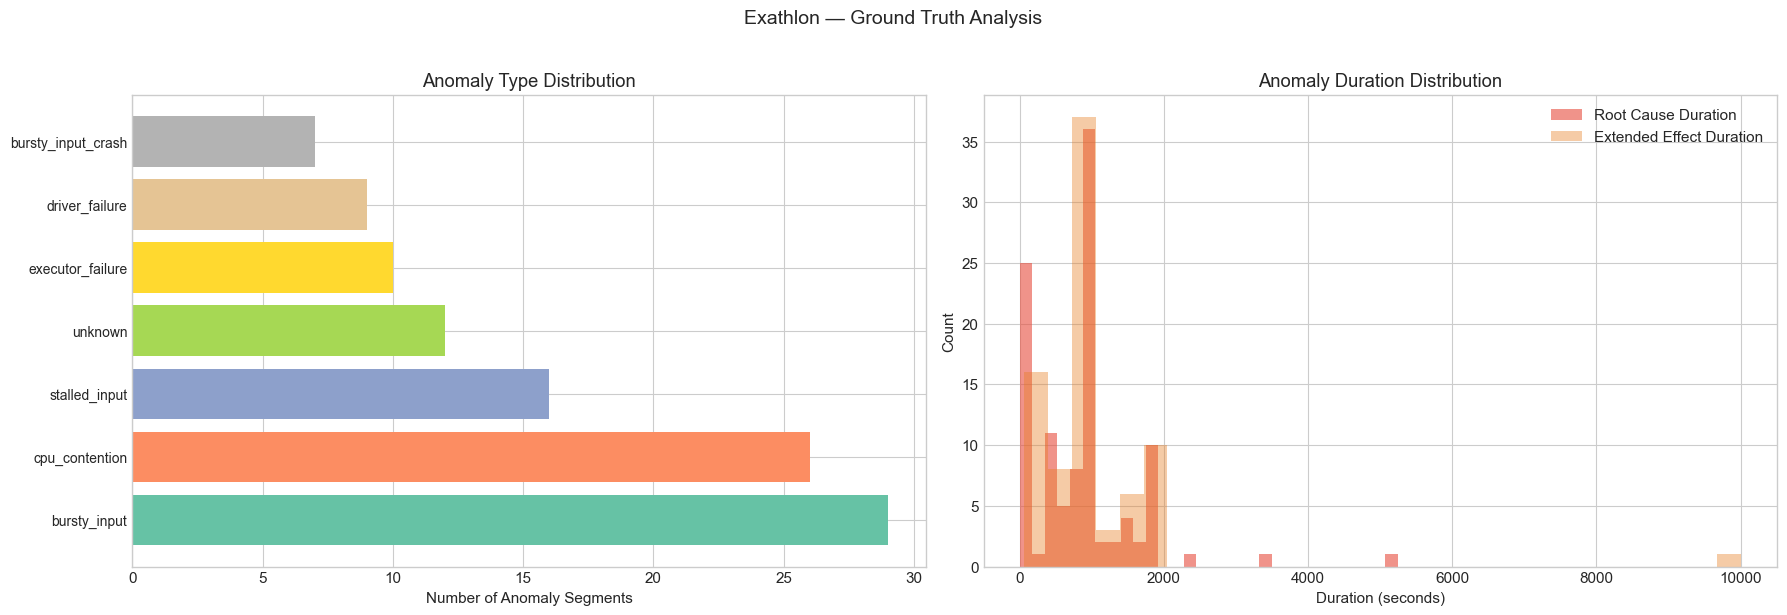

Total anomaly segments: 109
Anomaly types: 7
Mean root cause duration: 838 seconds
Mean extended effect: 1038 seconds


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Anomaly type distribution
type_counts = gt['anomaly_type'].value_counts()
axes[0].barh(range(len(type_counts)), type_counts.values, color=plt.cm.Set2(np.linspace(0, 1, len(type_counts))))
axes[0].set_yticks(range(len(type_counts)))
axes[0].set_yticklabels(type_counts.index, fontsize=10)
axes[0].set_xlabel('Number of Anomaly Segments')
axes[0].set_title('Anomaly Type Distribution')

# Anomaly duration distribution
gt['duration'] = gt['root_cause_end'] - gt['root_cause_start']
gt['extended_duration'] = gt['extended_effect_end'] - gt['root_cause_start']

axes[1].hist(gt['duration'], bins=30, alpha=0.6, color='#e74c3c', label='Root Cause Duration')
axes[1].hist(gt['extended_duration'], bins=30, alpha=0.4, color='#e67e22', label='Extended Effect Duration')
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_ylabel('Count')
axes[1].set_title('Anomaly Duration Distribution')
axes[1].legend()

plt.suptitle('Exathlon — Ground Truth Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Total anomaly segments: {len(gt)}")
print(f"Anomaly types: {len(type_counts)}")
print(f"Mean root cause duration: {gt['duration'].mean():.0f} seconds")
print(f"Mean extended effect: {gt['extended_duration'].mean():.0f} seconds")


## 4. Cross-Application Comparison — Clustering Potential

The 10 Spark applications have different workloads and resource profiles. This creates a natural basis for **application-level clustering** — grouping applications by their operational signatures.


Common features across all apps: 100


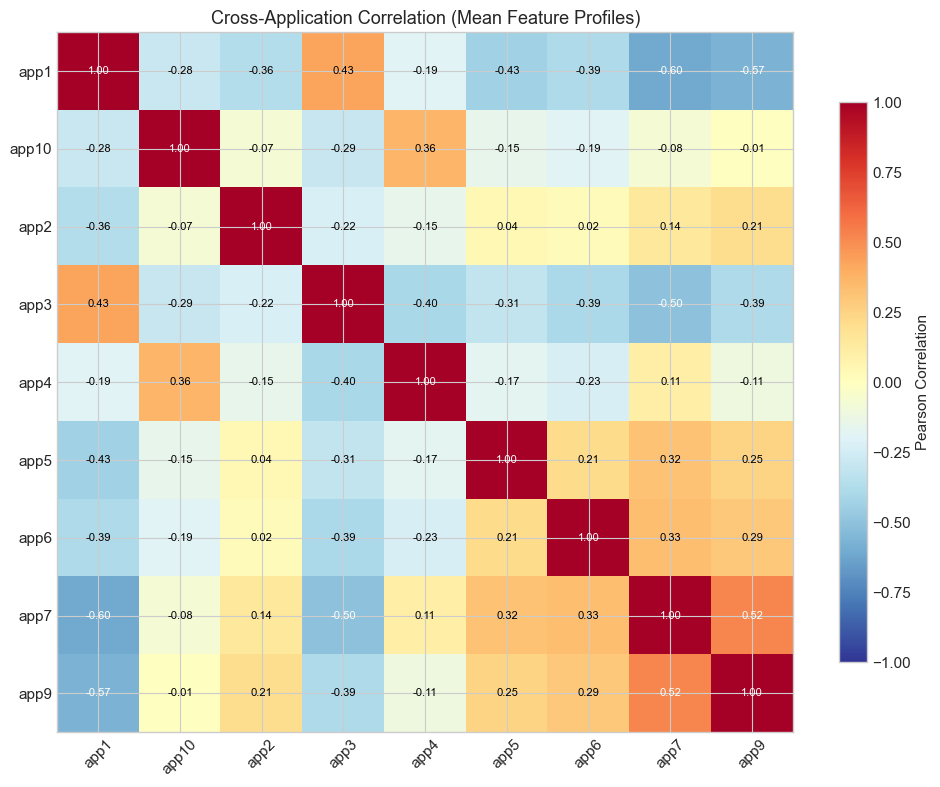

Key Insight: Applications with similar workloads show higher correlation,
forming natural clusters for MTS clustering research.


In [7]:
# Load one normal trace from each available app and compare
app_profiles = {}
app_columns = {}
for app in apps:
    app_dir = os.path.join(RAW_DIR, app)
    traces = sorted([f for f in os.listdir(app_dir) if f.endswith('.zip') and '_0_' in f])
    if traces:
        try:
            df = load_trace(app, traces[0])
            feature_cols_app = [c for c in df.columns if c != 't']
            app_columns[app] = feature_cols_app
            means = {}
            for c in feature_cols_app:
                vals = df[c].values
                valid = vals[vals != -1]
                means[c] = np.mean(valid) if len(valid) > 0 else 0
            app_profiles[app] = means
        except Exception as e:
            print(f"Could not load {app}: {e}")

if len(app_profiles) > 1:
    # Find common columns across all apps
    app_names = sorted(app_profiles.keys())
    common_cols = set(app_columns[app_names[0]])
    for a in app_names[1:]:
        common_cols = common_cols & set(app_columns[a])
    common_cols = sorted(list(common_cols))[:100]
    print(f"Common features across all apps: {len(common_cols)}")
    
    profile_matrix = np.array([[app_profiles[a].get(c, 0) for c in common_cols] for a in app_names])
    
    # Normalize
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaled = scaler.fit_transform(profile_matrix)
    
    corr = np.corrcoef(scaled)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(app_names)))
    ax.set_yticks(range(len(app_names)))
    ax.set_xticklabels(app_names, rotation=45)
    ax.set_yticklabels(app_names)
    ax.set_title('Cross-Application Correlation (Mean Feature Profiles)', fontsize=13)
    plt.colorbar(im, ax=ax, label='Pearson Correlation', shrink=0.8)
    
    # Annotate
    for i in range(len(app_names)):
        for j in range(len(app_names)):
            ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=8,
                   color='white' if abs(corr[i,j]) > 0.5 else 'black')
    
    plt.tight_layout()
    plt.show()
    print("Key Insight: Applications with similar workloads show higher correlation,")
    print("forming natural clusters for MTS clustering research.")


## 5. Feature Sparsity and Missing Value Analysis

With 2,283 features, understanding the sparsity pattern is crucial. Many features may be constant or missing (-1) for specific applications.


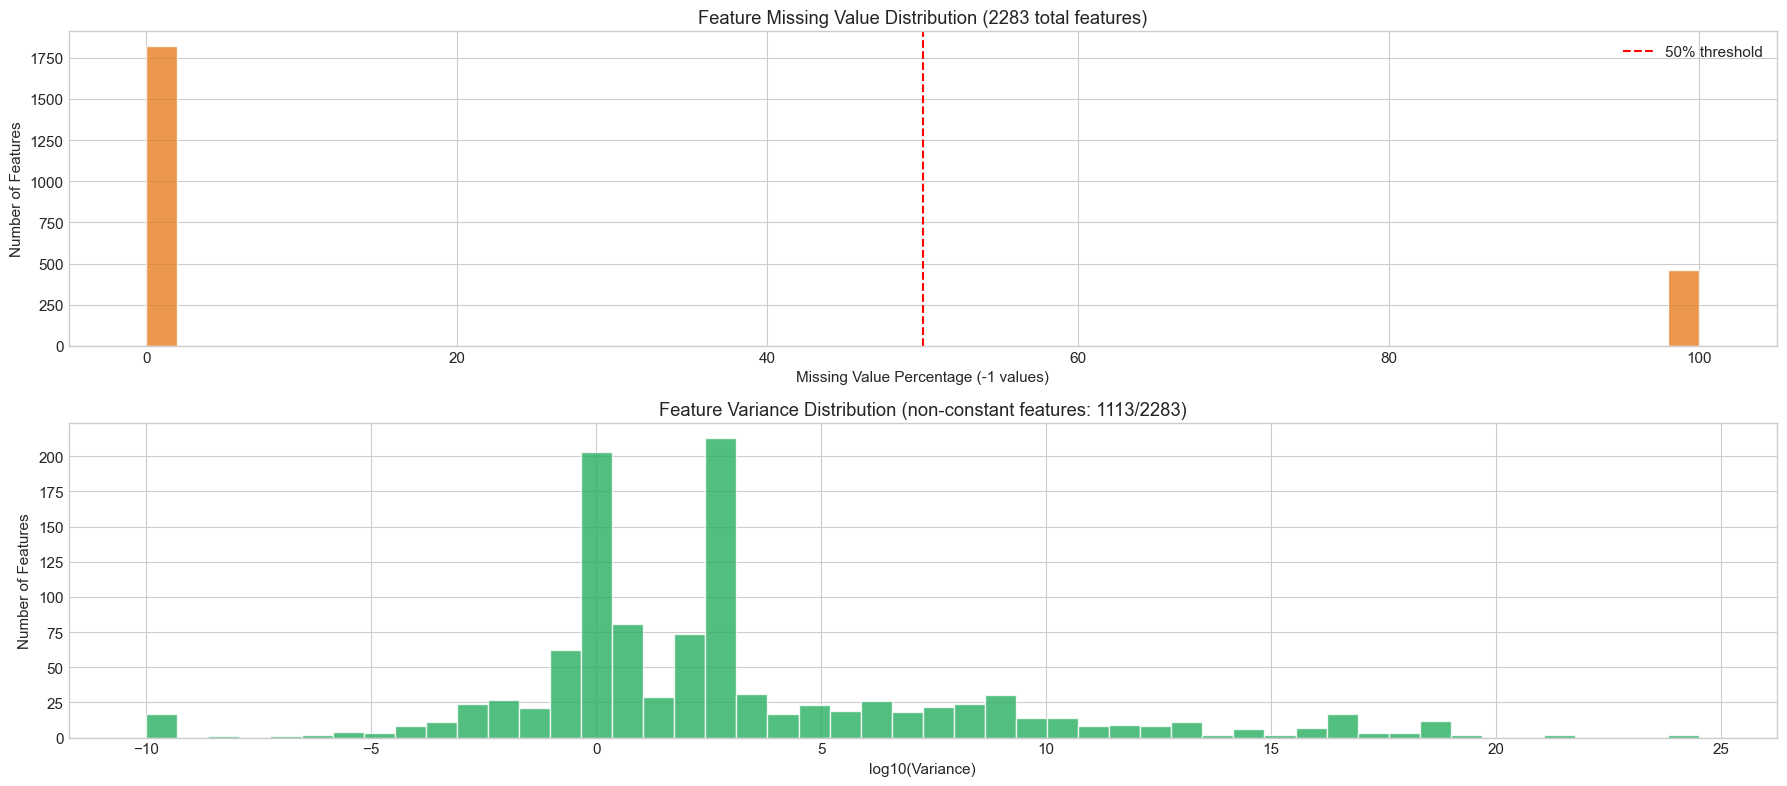

Total features: 2283
Features with >50% missing: 462
Constant features: 645
Usable features (varying, <50% missing): 1638


In [8]:
if normal_traces:
    df = normal_df.copy()
    feature_cols_sparsity = [c for c in df.columns if c != 't']
    
    # Analyze feature properties
    missing_pct = (df[feature_cols_sparsity] == -1).mean() * 100
    constant_pct = (df[feature_cols_sparsity].std() == 0).astype(float) * 100
    
    fig, axes = plt.subplots(2, 1, figsize=(18, 8))
    
    # Missing value distribution
    axes[0].hist(missing_pct.values, bins=50, color='#e67e22', edgecolor='white', alpha=0.8)
    axes[0].set_xlabel('Missing Value Percentage (-1 values)')
    axes[0].set_ylabel('Number of Features')
    axes[0].set_title(f'Feature Missing Value Distribution ({len(feature_cols_sparsity)} total features)')
    axes[0].axvline(x=50, color='red', linestyle='--', label='50% threshold')
    axes[0].legend()
    
    # Feature variance distribution (log scale for non-constant features)
    variances = df[feature_cols_sparsity].replace(-1, np.nan).var()
    non_zero_var = variances[variances > 0]
    axes[1].hist(np.log10(non_zero_var.values + 1e-10), bins=50, color='#27ae60', edgecolor='white', alpha=0.8)
    axes[1].set_xlabel('log10(Variance)')
    axes[1].set_ylabel('Number of Features')
    axes[1].set_title(f'Feature Variance Distribution (non-constant features: {len(non_zero_var)}/{len(feature_cols_sparsity)})')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total features: {len(feature_cols_sparsity)}")
    print(f"Features with >50% missing: {(missing_pct > 50).sum()}")
    print(f"Constant features: {(df[feature_cols_sparsity].std() == 0).sum()}")
    print(f"Usable features (varying, <50% missing): {((missing_pct <= 50) & (df[feature_cols_sparsity].std() > 0)).sum()}")


## Summary: How Exathlon Supports Your Research

### Unsupervised Anomaly Detection
- **Multiple anomaly types** (bursty input, CPU contention, etc.) with root cause annotations
- **Explainable AD**: Ground truth includes which time period is affected and why
- **Ultra-high dimensionality** (2,283 features) — challenges scalability of existing methods
- Suitable for MTAD-GAT, reconstruction-based, and forecasting-based approaches

### MTS Clustering
- **10 different applications** with distinct workload profiles
- Cross-application similarity analysis reveals natural clusters
- TICC can discover operational regimes within and across applications

### Predictive Maintenance / Early Detection
- Anomalies have **extended effect periods** beyond root cause — early detection is meaningful
- Root cause timing enables evaluation of early warning capabilities
- Cloud/edge infrastructure monitoring is critical for Industry 5.0

### Complexity Assessment
- **Highly complex**: 2,283 dimensions, multiple anomaly types, sparse features
- **Active research area**: Explainable anomaly detection is a growing field
- **Unique challenges**: Feature selection, dimensionality reduction, and interpretability
- **Under-explored for clustering**: Most prior work focuses on detection, not clustering


## 6. Temporal Regime Analysis Within Applications

Even within a single normal trace, Spark applications transition through different processing phases (e.g., initialization, steady-state processing, garbage collection pauses, batch boundary effects). These **temporal regimes** are the operational clusters that methods like TICC discover — they are NOT anomaly types, but rather distinct modes of system behavior.

Below we analyze rolling statistics to reveal these regime transitions.

Non-trivial features for regime analysis: 1113


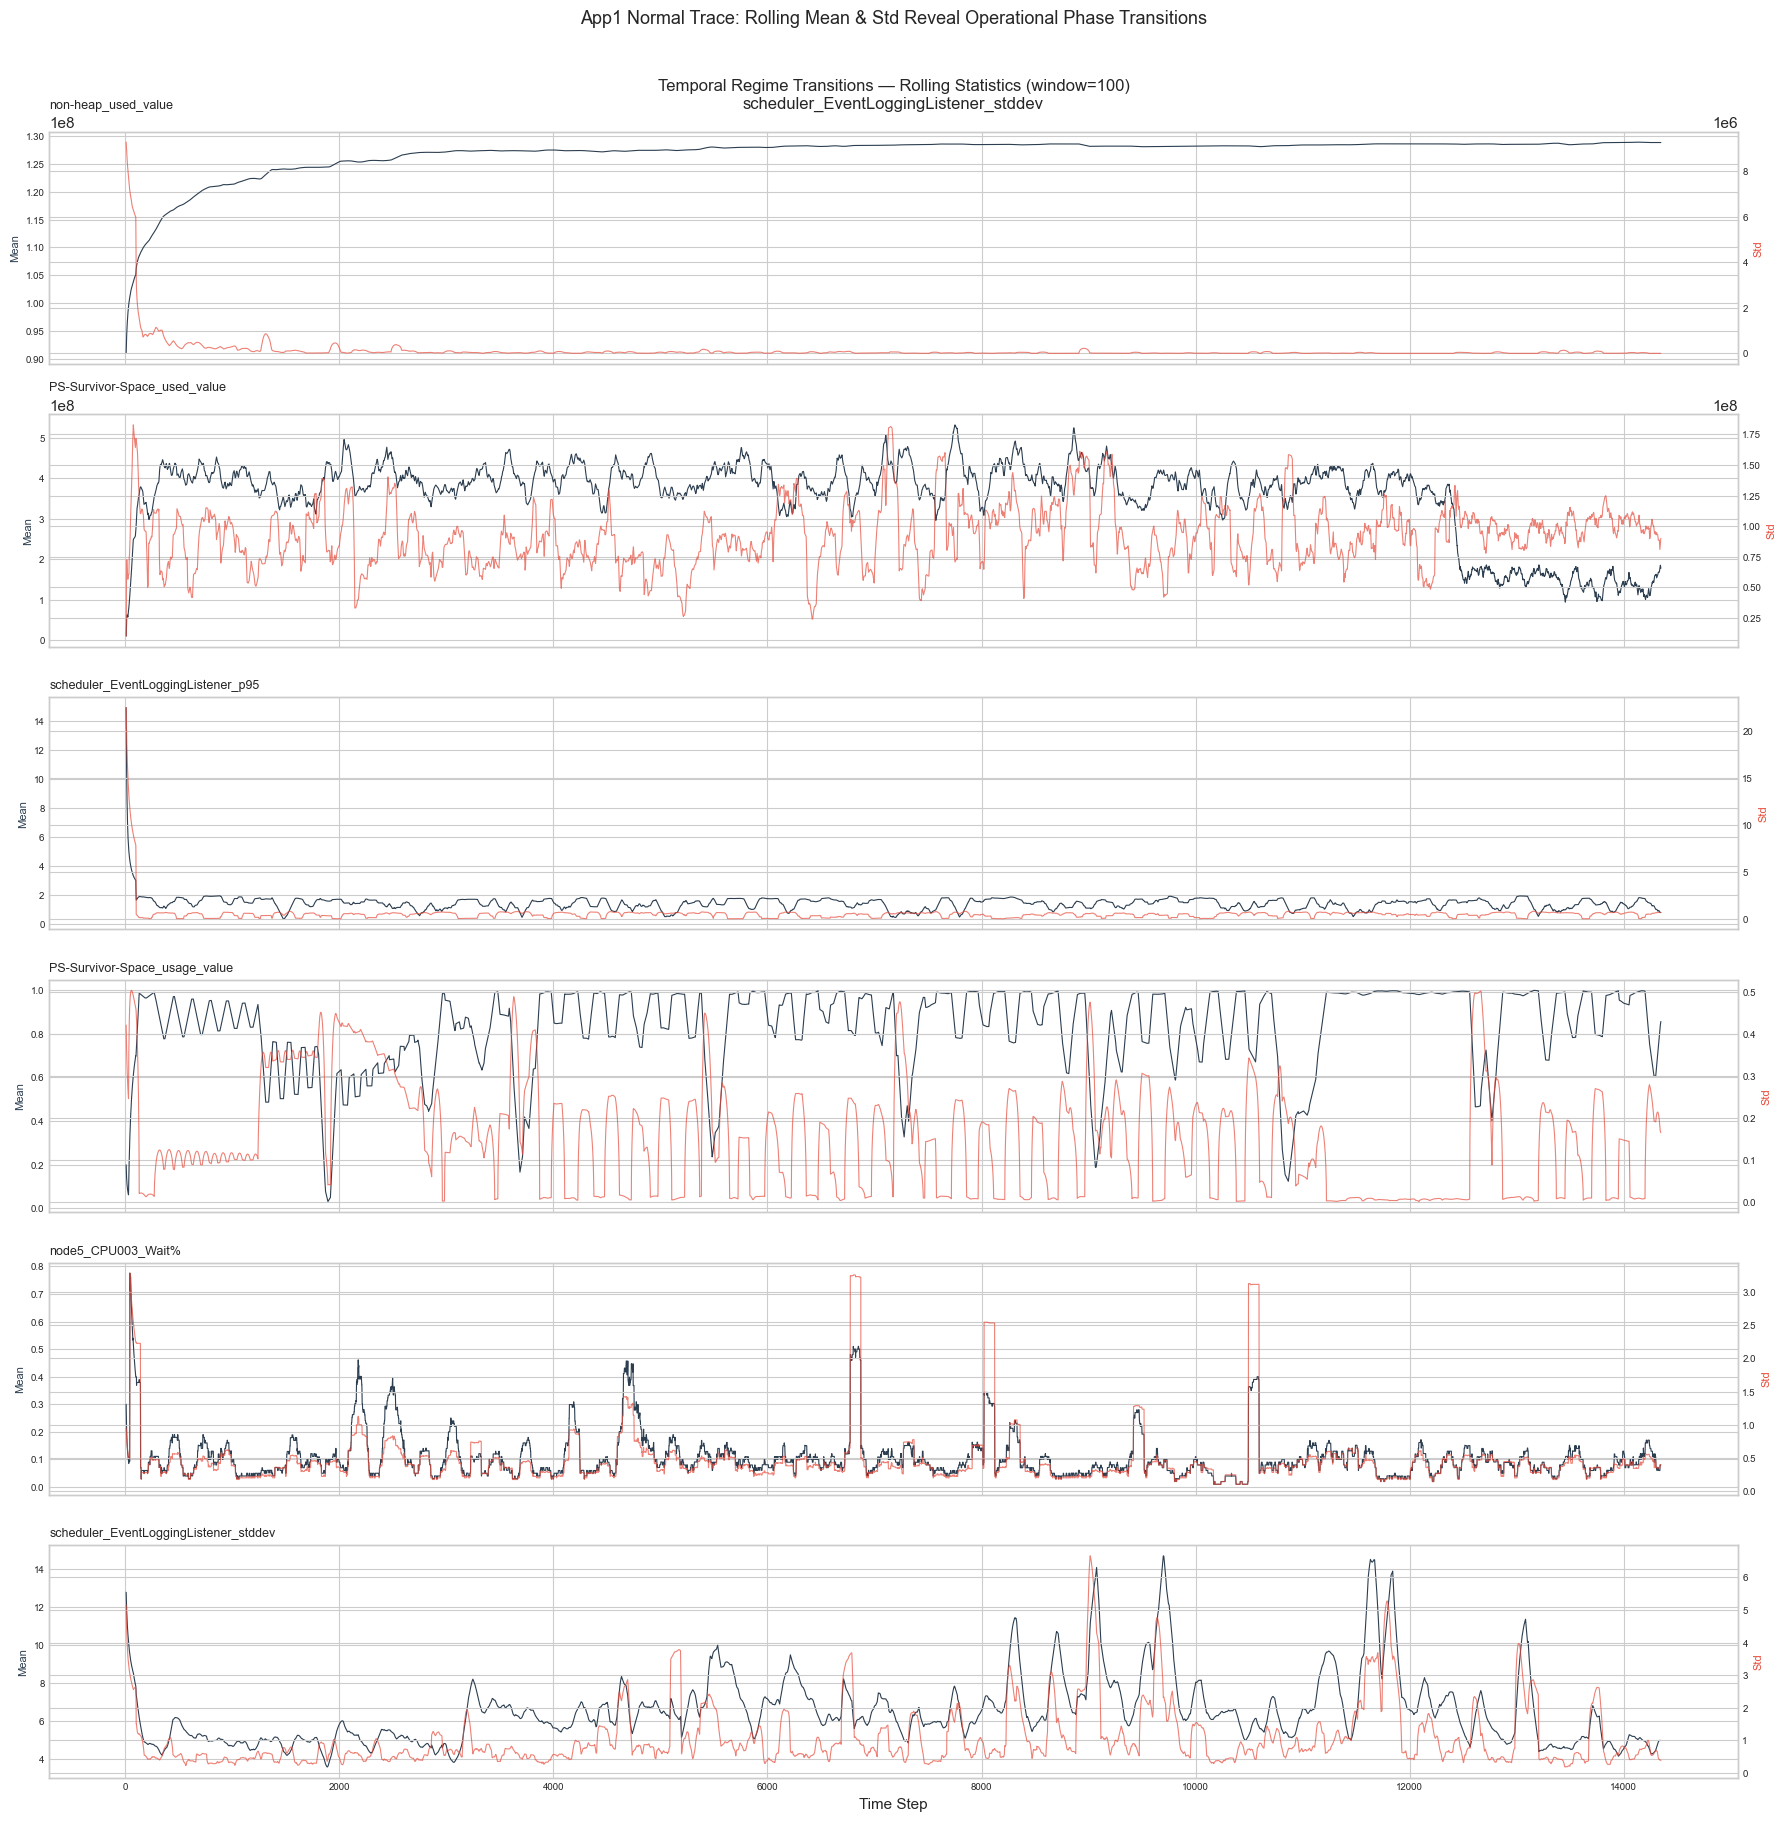

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

# --- Temporal Regime Analysis on a normal trace from app1 ---
# Reload the normal trace
app1_dir = os.path.join(RAW_DIR, 'app1')
app1_normal = sorted([f for f in os.listdir(app1_dir) if f.endswith('.zip') and '_0_' in f])
df_regime = load_trace('app1', app1_normal[0])

# Identify non-trivial features (varying, mostly non-missing)
feature_cols_regime = [c for c in df_regime.columns if c != 't']
non_trivial_regime = []
for c in feature_cols_regime:
    vals = df_regime[c].values.copy()
    valid = vals[vals != -1]
    if len(valid) > 0.5 * len(vals) and np.std(valid) > 0:
        non_trivial_regime.append(c)

print(f"Non-trivial features for regime analysis: {len(non_trivial_regime)}")

# Select a diverse subset of features based on different metric categories
np.random.seed(123)
selected_regime = np.random.choice(non_trivial_regime[:300], size=min(6, len(non_trivial_regime)), replace=False)

# Compute rolling statistics (window=100)
WINDOW = 100
rolling_data = {}
for col in selected_regime:
    vals = df_regime[col].values.copy().astype(float)
    vals[vals == -1] = np.nan
    series = pd.Series(vals)
    rolling_data[col] = {
        'mean': series.rolling(WINDOW, min_periods=10).mean().values,
        'std': series.rolling(WINDOW, min_periods=10).std().values,
    }

# --- Plot 1: Rolling mean and std over time for selected features ---
fig, axes = plt.subplots(len(selected_regime), 1, figsize=(18, 3 * len(selected_regime)), sharex=True)
time_axis = np.arange(len(df_regime))

for i, col in enumerate(selected_regime):
    ax = axes[i]
    ax2 = ax.twinx()
    
    short_name = '_'.join(col.split('_')[-3:])
    
    ax.plot(time_axis, rolling_data[col]['mean'], color='#2c3e50', linewidth=0.8, label='Rolling Mean')
    ax2.plot(time_axis, rolling_data[col]['std'], color='#e74c3c', linewidth=0.8, alpha=0.7, label='Rolling Std')
    
    ax.set_ylabel('Mean', fontsize=8, color='#2c3e50')
    ax2.set_ylabel('Std', fontsize=8, color='#e74c3c')
    ax.set_title(f'{short_name}', fontsize=9, loc='left')
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7)

axes[-1].set_xlabel('Time Step')
axes[0].set_title(f'Temporal Regime Transitions — Rolling Statistics (window={WINDOW})\n{short_name}',
                   fontsize=12)
plt.suptitle(f'App1 Normal Trace: Rolling Mean & Std Reveal Operational Phase Transitions', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

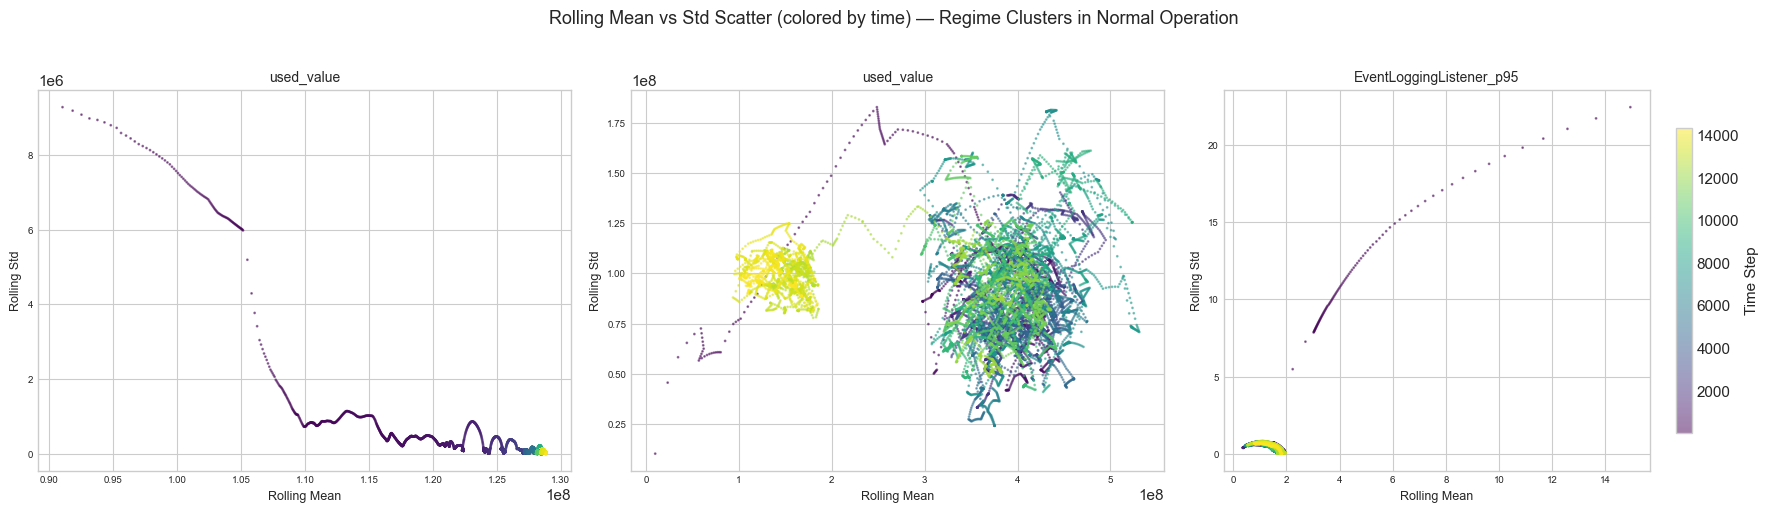

Interpretation: Distinct clusters in the mean-std space correspond to different
operational regimes (e.g., low-load vs high-load processing phases).
The color gradient shows temporal ordering — regime transitions are visible as
jumps between clusters. These are the regimes TICC-style methods would discover.


In [10]:
# --- Plot 2: Rolling Mean vs Rolling Std scatter colored by time ---
# This reveals regime clusters: points that cluster together represent similar operational phases

# Use 3 representative features for a compact scatter view
scatter_features = selected_regime[:3]

fig, axes = plt.subplots(1, len(scatter_features), figsize=(18, 5))

for i, col in enumerate(scatter_features):
    ax = axes[i]
    r_mean = rolling_data[col]['mean']
    r_std = rolling_data[col]['std']
    
    # Remove NaN entries
    valid_mask = ~(np.isnan(r_mean) | np.isnan(r_std))
    r_mean_v = r_mean[valid_mask]
    r_std_v = r_std[valid_mask]
    time_v = time_axis[valid_mask]
    
    sc = ax.scatter(r_mean_v, r_std_v, c=time_v, cmap='viridis', s=1, alpha=0.5)
    
    short_name = '_'.join(col.split('_')[-2:])
    ax.set_xlabel('Rolling Mean', fontsize=9)
    ax.set_ylabel('Rolling Std', fontsize=9)
    ax.set_title(short_name, fontsize=10)
    ax.tick_params(labelsize=7)

plt.colorbar(sc, ax=axes[-1], label='Time Step', shrink=0.8)
plt.suptitle('Rolling Mean vs Std Scatter (colored by time) — Regime Clusters in Normal Operation',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation: Distinct clusters in the mean-std space correspond to different")
print("operational regimes (e.g., low-load vs high-load processing phases).")
print("The color gradient shows temporal ordering — regime transitions are visible as")
print("jumps between clusters. These are the regimes TICC-style methods would discover.")

Even within normal operation, Spark applications transition between processing phases. These temporal regimes are the clusters that TICC-style methods discover. Key observations:

- **Regime transitions** are visible as abrupt shifts in rolling statistics (mean level changes, variance spikes)
- **Mean-vs-Std scatter plots** reveal natural clusters corresponding to distinct operational phases
- **Temporal coloring** shows that regimes are not random but follow a structured temporal progression
- This is fundamentally different from anomaly detection: a "cluster" here is an operational mode, not an anomaly type. Anomalies can occur *within* any regime.

## 7. Anomaly Root Cause Timing — Early Detection Window

The Exathlon ground truth provides three critical timestamps per anomaly segment: `root_cause_start`, `root_cause_end`, and `extended_effect_end`. The gap between root cause start and extended effect end defines the **propagation window** — the time during which early detection methods could raise an alarm before full system degradation.

Understanding this window is essential for:
- **Early prediction**: How much lead time do we have?
- **Predictive maintenance**: Can we detect degradation before it becomes critical?
- **Remaining useful lifetime**: How long until the anomaly fully propagates?

Anomaly segments with valid timing: 81 / 109

--- Propagation Window Statistics (seconds) ---
  Mean: 1038s (17.3 min)
  Median: 967s (16.1 min)
  Min: 62s
  Max: 10005s (166.8 min)

--- Root Cause Duration Statistics (seconds) ---
  Mean: 806s
  Median: 899s

--- Effect After Root Cause (early detection opportunity) ---
  Mean: 232s (3.9 min)
  Median: 68s


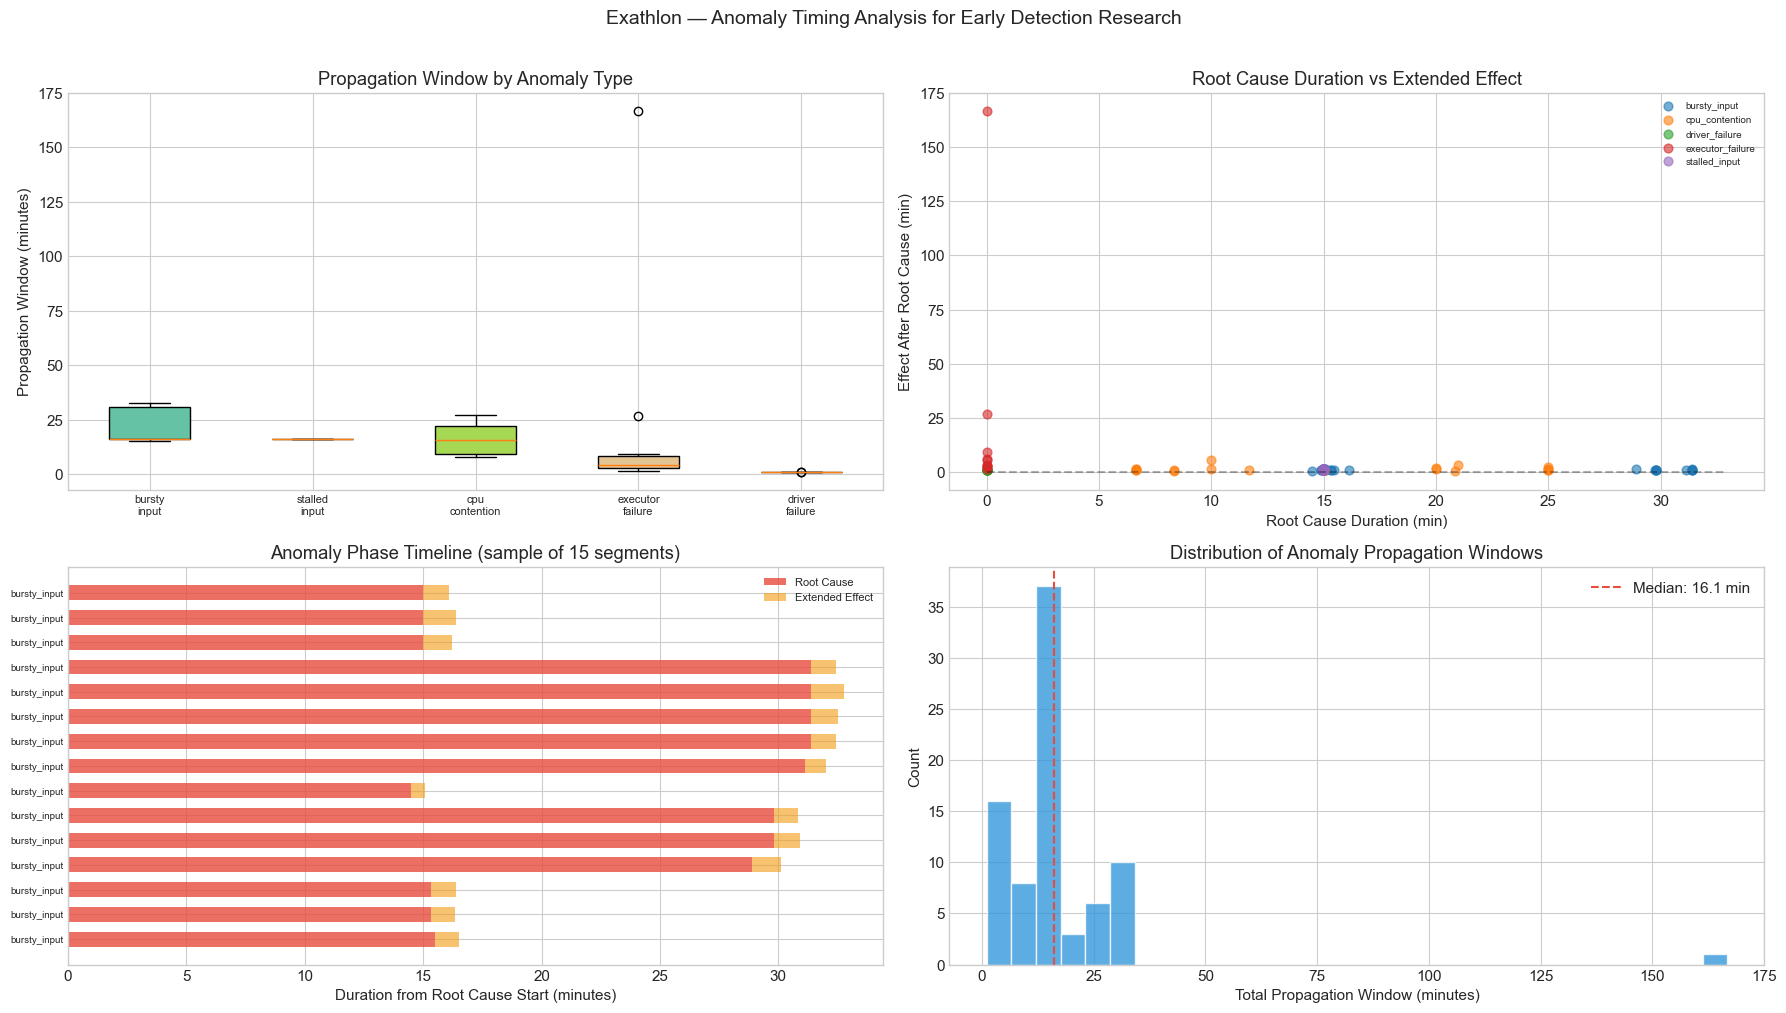

In [11]:
# --- Anomaly Propagation Window Analysis ---
gt_analysis = gt.copy()

# Compute timing metrics
gt_analysis['root_cause_duration'] = gt_analysis['root_cause_end'] - gt_analysis['root_cause_start']
gt_analysis['propagation_window'] = gt_analysis['extended_effect_end'] - gt_analysis['root_cause_start']
gt_analysis['effect_after_root_cause'] = gt_analysis['extended_effect_end'] - gt_analysis['root_cause_end']

# Filter out rows with missing timing data
gt_valid = gt_analysis[
    (gt_analysis['root_cause_start'] > 0) & 
    (gt_analysis['root_cause_end'] > 0) & 
    (gt_analysis['extended_effect_end'] > 0) &
    (gt_analysis['propagation_window'] > 0)
].copy()

print(f"Anomaly segments with valid timing: {len(gt_valid)} / {len(gt_analysis)}")
print(f"\n--- Propagation Window Statistics (seconds) ---")
print(f"  Mean: {gt_valid['propagation_window'].mean():.0f}s ({gt_valid['propagation_window'].mean()/60:.1f} min)")
print(f"  Median: {gt_valid['propagation_window'].median():.0f}s ({gt_valid['propagation_window'].median()/60:.1f} min)")
print(f"  Min: {gt_valid['propagation_window'].min():.0f}s")
print(f"  Max: {gt_valid['propagation_window'].max():.0f}s ({gt_valid['propagation_window'].max()/60:.1f} min)")
print(f"\n--- Root Cause Duration Statistics (seconds) ---")
print(f"  Mean: {gt_valid['root_cause_duration'].mean():.0f}s")
print(f"  Median: {gt_valid['root_cause_duration'].median():.0f}s")
print(f"\n--- Effect After Root Cause (early detection opportunity) ---")
print(f"  Mean: {gt_valid['effect_after_root_cause'].mean():.0f}s ({gt_valid['effect_after_root_cause'].mean()/60:.1f} min)")
print(f"  Median: {gt_valid['effect_after_root_cause'].median():.0f}s")

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. Propagation window by anomaly type
ax = axes[0, 0]
types_order = gt_valid.groupby('anomaly_type')['propagation_window'].median().sort_values(ascending=False).index
bp_data = [gt_valid[gt_valid['anomaly_type'] == t]['propagation_window'].values / 60 for t in types_order]
bp = ax.boxplot(bp_data, labels=[t.replace('_', '\n') for t in types_order], patch_artist=True)
colors_bp = plt.cm.Set2(np.linspace(0, 1, len(types_order)))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
ax.set_ylabel('Propagation Window (minutes)')
ax.set_title('Propagation Window by Anomaly Type')
ax.tick_params(axis='x', labelsize=8)

# 2. Root cause duration vs extended effect
ax = axes[0, 1]
for atype in gt_valid['anomaly_type'].unique():
    mask = gt_valid['anomaly_type'] == atype
    ax.scatter(gt_valid.loc[mask, 'root_cause_duration'] / 60,
               gt_valid.loc[mask, 'effect_after_root_cause'] / 60,
               label=atype, alpha=0.6, s=40)
ax.set_xlabel('Root Cause Duration (min)')
ax.set_ylabel('Effect After Root Cause (min)')
ax.set_title('Root Cause Duration vs Extended Effect')
ax.legend(fontsize=7, loc='upper right')
ax.plot([0, ax.get_xlim()[1]], [0, 0], 'k--', alpha=0.3)

# 3. Timeline view of anomaly phases
ax = axes[1, 0]
sample_gt = gt_valid.head(15).reset_index(drop=True)
for i, (_, row) in enumerate(sample_gt.iterrows()):
    t0 = row['root_cause_start']
    rc_dur = row['root_cause_duration']
    eff_dur = row['effect_after_root_cause']
    ax.barh(i, rc_dur / 60, left=0, color='#e74c3c', alpha=0.8, height=0.6, label='Root Cause' if i == 0 else '')
    ax.barh(i, eff_dur / 60, left=rc_dur / 60, color='#f39c12', alpha=0.6, height=0.6, label='Extended Effect' if i == 0 else '')
ax.set_yticks(range(len(sample_gt)))
ax.set_yticklabels([f"{r['anomaly_type'][:12]}" for _, r in sample_gt.iterrows()], fontsize=7)
ax.set_xlabel('Duration from Root Cause Start (minutes)')
ax.set_title('Anomaly Phase Timeline (sample of 15 segments)')
ax.legend(fontsize=8)

# 4. Distribution of propagation windows
ax = axes[1, 1]
ax.hist(gt_valid['propagation_window'].values / 60, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(gt_valid['propagation_window'].median() / 60, color='#e74c3c', linestyle='--', 
           label=f'Median: {gt_valid["propagation_window"].median()/60:.1f} min')
ax.set_xlabel('Total Propagation Window (minutes)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Anomaly Propagation Windows')
ax.legend()

plt.suptitle('Exathlon — Anomaly Timing Analysis for Early Detection Research', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Anomalous trace: 1_2_100000_68
Trace shape: (2936, 2284)
Ground truth entries for this trace: 1
Anomaly type: bursty_input_crash
Root cause start: 1528363151.0
Root cause end: 1528365472.0
Extended effect end: nan

Top precursor signal features (z-score of mean shift before anomaly):
  node5_CPU002_User%: z=34.94
  node5_CPU032_User%: z=33.53
  node5_CPU032_Idle%: z=23.18
  node5_CPU001_User%: z=19.48


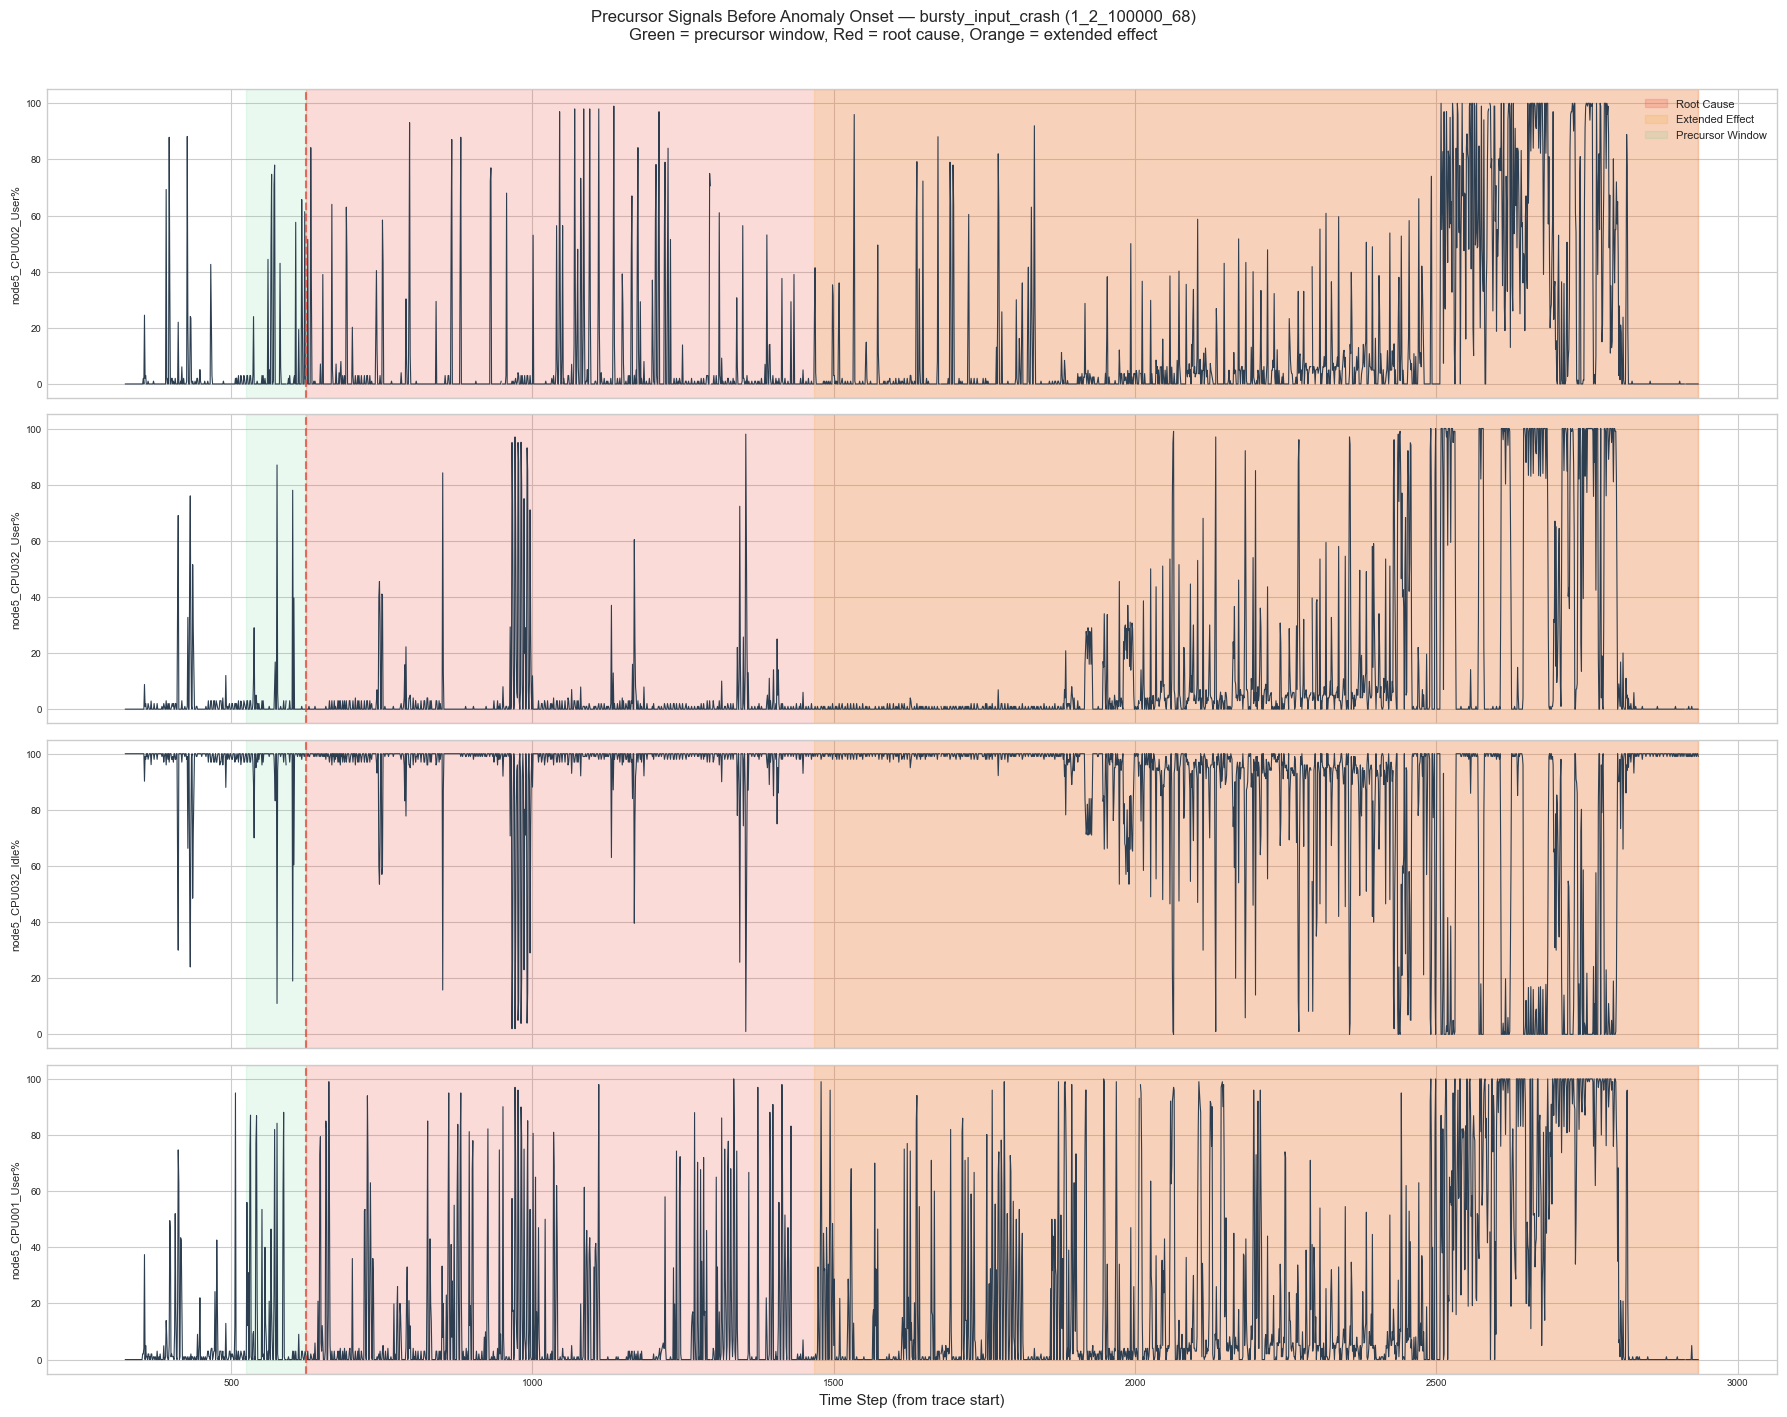

In [12]:
import pandas as pd
import os
# --- Precursor Signal Analysis: Zoom into region BEFORE root cause start ---
# Load an anomalous trace and examine feature behavior leading up to anomaly onset

app1_anom = sorted([f for f in os.listdir(os.path.join(RAW_DIR, 'app1')) 
                    if f.endswith('.zip') and '_0_' not in f])

if app1_anom:
    df_anom = load_trace('app1', app1_anom[0])
    trace_name = app1_anom[0].replace('.zip', '')
    trace_gt = gt[gt['trace_name'] == trace_name]
    
    print(f"Anomalous trace: {trace_name}")
    print(f"Trace shape: {df_anom.shape}")
    print(f"Ground truth entries for this trace: {len(trace_gt)}")
    
    if len(trace_gt) > 0:
        row = trace_gt.iloc[0]
        print(f"Anomaly type: {row['anomaly_type']}")
        print(f"Root cause start: {row['root_cause_start']}")
        print(f"Root cause end: {row['root_cause_end']}")
        print(f"Extended effect end: {row['extended_effect_end']}")
        
        t_start = df_anom['t'].min()
        rc_start_idx = int(row['root_cause_start'] - t_start) if pd.notna(row['root_cause_start']) else 0
        rc_end_idx = int(row['root_cause_end'] - t_start) if pd.notna(row['root_cause_end']) else len(df_anom)//2
        ee_end_idx = int(row['extended_effect_end'] - t_start) if pd.notna(row['extended_effect_end']) else len(df_anom)//2
        
        # Clamp indices
        rc_start_idx = max(0, min(rc_start_idx, len(df_anom) - 1))
        rc_end_idx = max(0, min(rc_end_idx, len(df_anom) - 1))
        ee_end_idx = max(0, min(ee_end_idx, len(df_anom) - 1))
        
        # Define the zoom window: 200 steps before root cause to 100 steps after root cause end
        precursor_window = 300
        post_window = 200
        zoom_start = max(0, rc_start_idx - precursor_window)
        zoom_end = min(len(df_anom), rc_end_idx + post_window)
        
        # Find features that show precursor signals (change before root cause)
        feature_cols_anom = [c for c in df_anom.columns if c != 't']
        non_trivial_anom = []
        for c in feature_cols_anom:
            vals = df_anom[c].values.copy()
            valid = vals[vals != -1]
            if len(valid) > 0.5 * len(vals) and np.std(valid) > 0:
                non_trivial_anom.append(c)
        
        # Score features by how much they change in the precursor window vs baseline
        precursor_scores = {}
        baseline_end = max(0, rc_start_idx - precursor_window)
        baseline_start = max(0, baseline_end - 500)
        
        for c in non_trivial_anom[:500]:  # Check first 500 non-trivial features
            vals = df_anom[c].values.copy().astype(float)
            vals[vals == -1] = np.nan
            
            baseline = vals[baseline_start:baseline_end]
            precursor = vals[max(0, rc_start_idx - 100):rc_start_idx]
            
            baseline_valid = baseline[~np.isnan(baseline)]
            precursor_valid = precursor[~np.isnan(precursor)]
            
            if len(baseline_valid) > 10 and len(precursor_valid) > 10:
                baseline_std = np.std(baseline_valid)
                if baseline_std > 0:
                    score = abs(np.mean(precursor_valid) - np.mean(baseline_valid)) / baseline_std
                    precursor_scores[c] = score
        
        # Select top features with strongest precursor signals
        top_precursor = sorted(precursor_scores, key=precursor_scores.get, reverse=True)[:4]
        
        print(f"\nTop precursor signal features (z-score of mean shift before anomaly):")
        for c in top_precursor:
            print(f"  {c}: z={precursor_scores[c]:.2f}")
        
        # Plot zoom view
        fig, axes = plt.subplots(len(top_precursor), 1, figsize=(18, 3.5 * len(top_precursor)), sharex=True)
        
        for i, col in enumerate(top_precursor):
            ax = axes[i]
            vals = df_anom[col].values.copy().astype(float)
            vals[vals == -1] = np.nan
            
            x = np.arange(zoom_start, zoom_end)
            y = vals[zoom_start:zoom_end]
            
            ax.plot(x, y, linewidth=0.8, color='#2c3e50')
            
            # Mark root cause region
            ax.axvspan(rc_start_idx, rc_end_idx, alpha=0.2, color='#e74c3c', label='Root Cause')
            ax.axvspan(rc_end_idx, min(ee_end_idx, zoom_end), alpha=0.15, color='#f39c12', label='Extended Effect')
            ax.axvline(rc_start_idx, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.8)
            
            # Mark precursor window
            ax.axvspan(rc_start_idx - 100, rc_start_idx, alpha=0.1, color='#2ecc71', label='Precursor Window')
            
            short_name = '_'.join(col.split('_')[-3:])
            ax.set_ylabel(short_name, fontsize=8)
            ax.tick_params(labelsize=7)
            if i == 0:
                ax.legend(fontsize=8, loc='upper right')
        
        axes[-1].set_xlabel('Time Step (from trace start)')
        plt.suptitle(f'Precursor Signals Before Anomaly Onset — {row["anomaly_type"]} ({trace_name})\n'
                      f'Green = precursor window, Red = root cause, Orange = extended effect',
                     fontsize=12, y=1.01)
        plt.tight_layout()
        plt.show()

The gap between `extended_effect_end` and `root_cause_start` defines the **propagation window** -- the time during which early detection is possible. Key findings:

- **Propagation windows vary significantly** across anomaly types, with some providing minutes of lead time
- **Precursor signals exist**: Some features show detectable shifts *before* the annotated root cause start, suggesting that early detection is feasible
- **Feature ranking by precursor z-score** identifies which dimensions are most useful for early warning systems
- This timing structure makes Exathlon suitable for evaluating early prediction methods, though the lead times may be short for some anomaly types

## 8. Dimensionality Analysis — Feature Selection Challenge

With 2,283 features, Exathlon presents one of the highest-dimensional MTS benchmarks. However, many features may be constant, mostly missing, or highly correlated. Understanding the **effective dimensionality** is critical for:
- Choosing appropriate anomaly detection methods (many scale poorly beyond ~100 dimensions)
- Identifying which features carry the most signal for clustering and detection
- Designing feature selection / dimensionality reduction pipelines

Total features (excluding timestamp): 2283
Features with at least some valid data: 1821
Usable features (<50% missing, non-constant): 1113


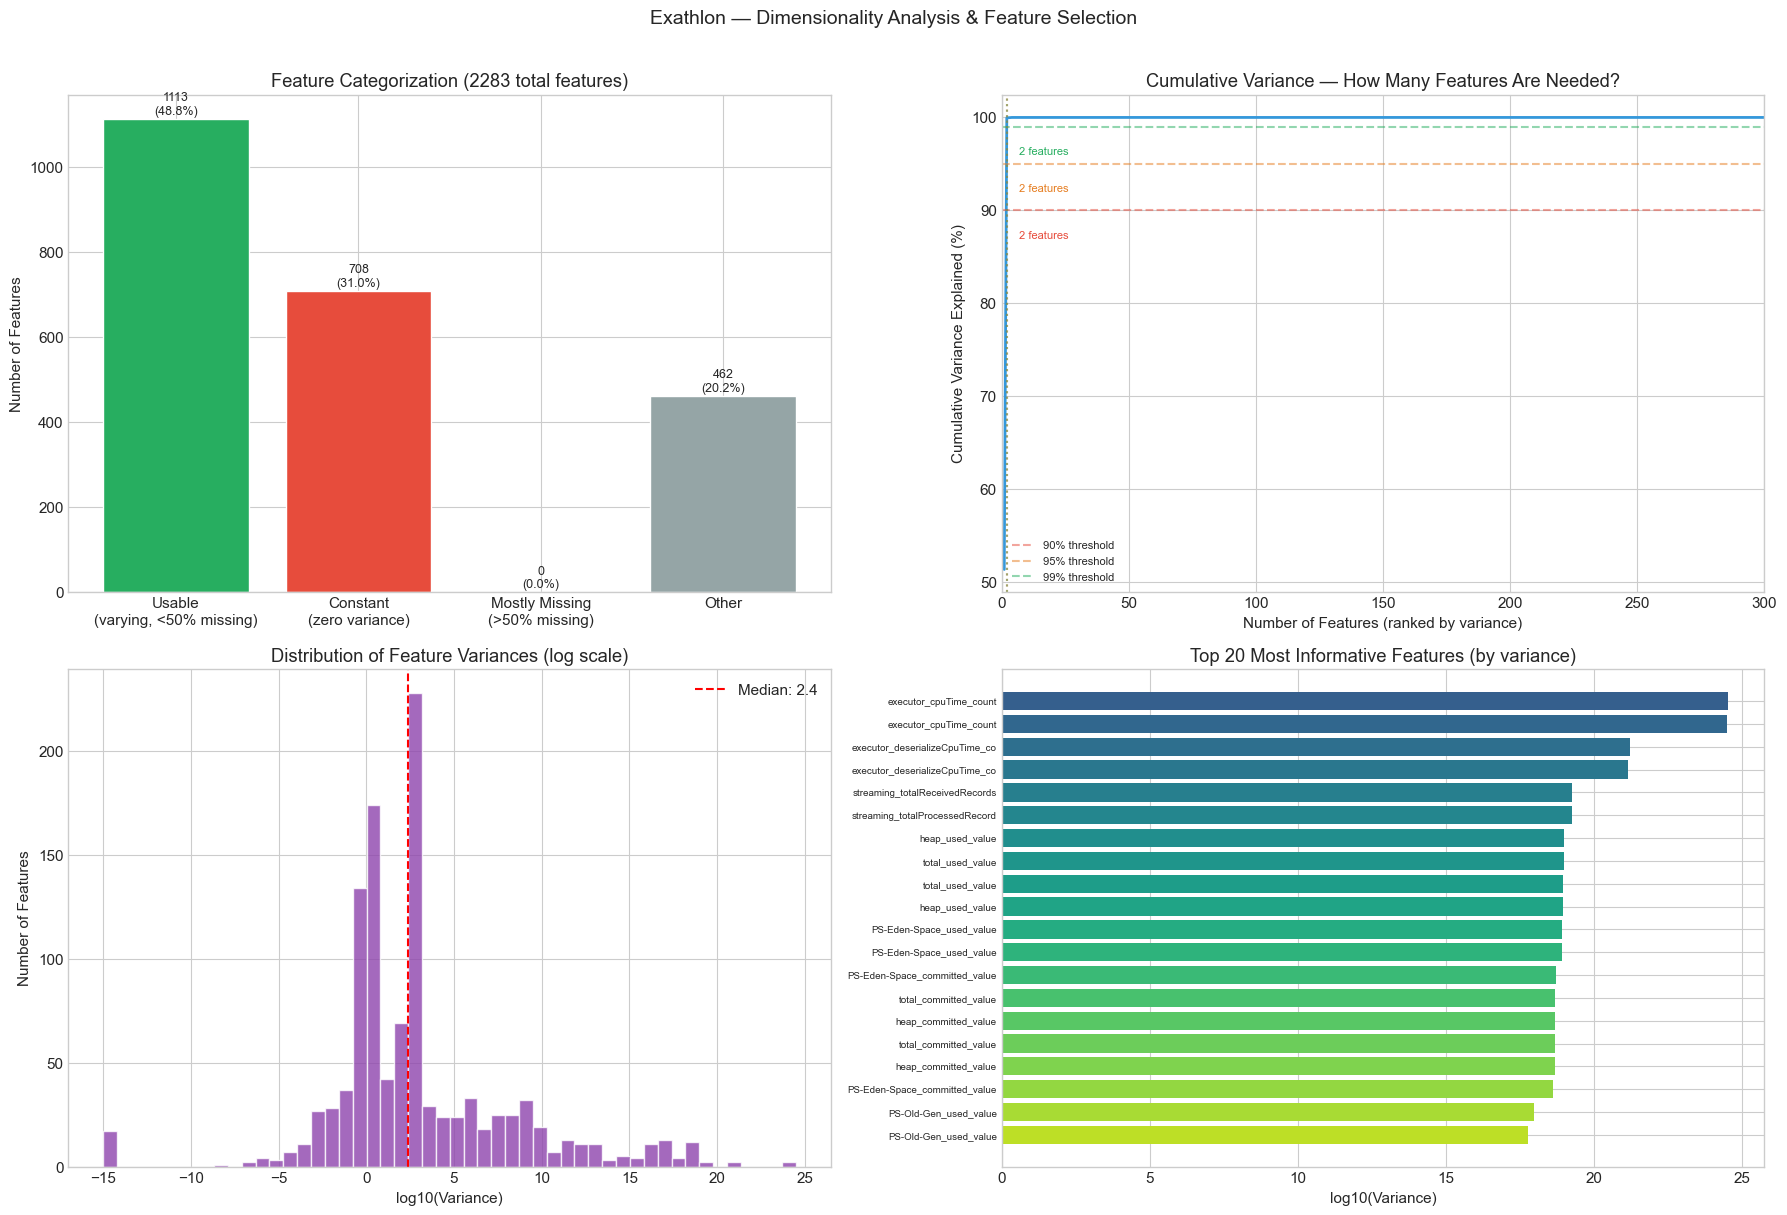


--- Dimensionality Reduction Summary ---
  Total features: 2283
  Usable features: 1113 (48.8%)
  Features for 90% variance: 2 (0.1% of total)
  Features for 95% variance: 2 (0.1% of total)
  Features for 99% variance: 2 (0.1% of total)

Top 5 most informative features:
  1_executor_cpuTime_count  (var=3.26e+24)
  2_executor_cpuTime_count  (var=3.09e+24)
  1_executor_deserializeCpuTime_count  (var=1.55e+21)
  2_executor_deserializeCpuTime_count  (var=1.37e+21)
  driver_benchmark_userclicks_1_19_10000_1000000_batch39_1__StreamingMetrics_streaming_totalReceivedRecords_value  (var=1.72e+19)


In [13]:
# --- Dimensionality Analysis: Feature Importance via Variance ---
# Use the normal trace from app1 for this analysis
df_dim = load_trace('app1', app1_normal[0])
feature_cols_dim = [c for c in df_dim.columns if c != 't']

print(f"Total features (excluding timestamp): {len(feature_cols_dim)}")

# Step 1: Filter features — remove constant and mostly-missing
feature_stats = []
for c in feature_cols_dim:
    vals = df_dim[c].values.copy().astype(float)
    missing_pct = (vals == -1).mean()
    vals_clean = vals.copy()
    vals_clean[vals_clean == -1] = np.nan
    valid = vals_clean[~np.isnan(vals_clean)]
    
    if len(valid) > 0:
        feature_stats.append({
            'feature': c,
            'missing_pct': missing_pct,
            'variance': np.var(valid),
            'std': np.std(valid),
            'mean': np.mean(valid),
            'cv': np.std(valid) / (abs(np.mean(valid)) + 1e-10),  # coefficient of variation
            'n_valid': len(valid),
        })

stats_df = pd.DataFrame(feature_stats)
print(f"Features with at least some valid data: {len(stats_df)}")

# Filter: remove mostly missing (>50%) and constant (variance=0) features
usable = stats_df[(stats_df['missing_pct'] <= 0.5) & (stats_df['variance'] > 0)].copy()
print(f"Usable features (<50% missing, non-constant): {len(usable)}")

# Step 2: Rank by variance (log scale to handle wide range)
usable_sorted = usable.sort_values('variance', ascending=False).reset_index(drop=True)
usable_sorted['rank'] = range(1, len(usable_sorted) + 1)
usable_sorted['log_variance'] = np.log10(usable_sorted['variance'] + 1e-15)

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Feature categorization breakdown
ax = axes[0, 0]
total = len(feature_cols_dim)
constant = len(stats_df[stats_df['variance'] == 0])
mostly_missing = len(stats_df[stats_df['missing_pct'] > 0.5]) - len(stats_df[(stats_df['missing_pct'] > 0.5) & (stats_df['variance'] == 0)])
usable_count = len(usable)
other_removed = total - constant - mostly_missing - usable_count

categories = ['Usable\n(varying, <50% missing)', 'Constant\n(zero variance)', 
              'Mostly Missing\n(>50% missing)', 'Other']
counts = [usable_count, constant, mostly_missing, other_removed]
colors_cat = ['#27ae60', '#e74c3c', '#f39c12', '#95a5a6']
bars = ax.bar(categories, counts, color=colors_cat, edgecolor='white')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'{count}\n({count/total*100:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('Number of Features')
ax.set_title(f'Feature Categorization ({total} total features)')

# 2. Cumulative variance explained (sorted by variance)
ax = axes[0, 1]
total_var = usable_sorted['variance'].sum()
cumulative_var = usable_sorted['variance'].cumsum() / total_var * 100
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var.values, color='#3498db', linewidth=2)
ax.axhline(y=90, color='#e74c3c', linestyle='--', alpha=0.5, label='90% threshold')
ax.axhline(y=95, color='#e67e22', linestyle='--', alpha=0.5, label='95% threshold')
ax.axhline(y=99, color='#27ae60', linestyle='--', alpha=0.5, label='99% threshold')

# Find how many features needed for each threshold
for thresh, color in [(90, '#e74c3c'), (95, '#e67e22'), (99, '#27ae60')]:
    n_feat = (cumulative_var >= thresh).idxmax() + 1
    ax.axvline(x=n_feat, color=color, linestyle=':', alpha=0.4)
    ax.text(n_feat + 5, thresh - 3, f'{n_feat} features', fontsize=8, color=color)

ax.set_xlabel('Number of Features (ranked by variance)')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.set_title('Cumulative Variance — How Many Features Are Needed?')
ax.legend(fontsize=8)
ax.set_xlim(0, min(300, len(usable_sorted)))

# 3. Log-variance distribution
ax = axes[1, 0]
ax.hist(usable_sorted['log_variance'].values, bins=50, color='#8e44ad', edgecolor='white', alpha=0.8)
ax.set_xlabel('log10(Variance)')
ax.set_ylabel('Number of Features')
ax.set_title('Distribution of Feature Variances (log scale)')
ax.axvline(usable_sorted['log_variance'].median(), color='red', linestyle='--',
           label=f'Median: {usable_sorted["log_variance"].median():.1f}')
ax.legend()

# 4. Top 20 most informative features
ax = axes[1, 1]
top20 = usable_sorted.head(20)
short_names = ['_'.join(f.split('_')[-3:])[:30] for f in top20['feature']]
ax.barh(range(len(top20)), top20['log_variance'].values, color=plt.cm.viridis(np.linspace(0.3, 0.9, 20)))
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(short_names, fontsize=7)
ax.set_xlabel('log10(Variance)')
ax.set_title('Top 20 Most Informative Features (by variance)')
ax.invert_yaxis()

plt.suptitle('Exathlon — Dimensionality Analysis & Feature Selection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print summary statistics
n_90 = (cumulative_var >= 90).idxmax() + 1
n_95 = (cumulative_var >= 95).idxmax() + 1
n_99 = (cumulative_var >= 99).idxmax() + 1
print(f"\n--- Dimensionality Reduction Summary ---")
print(f"  Total features: {total}")
print(f"  Usable features: {usable_count} ({usable_count/total*100:.1f}%)")
print(f"  Features for 90% variance: {n_90} ({n_90/total*100:.1f}% of total)")
print(f"  Features for 95% variance: {n_95} ({n_95/total*100:.1f}% of total)")
print(f"  Features for 99% variance: {n_99} ({n_99/total*100:.1f}% of total)")
print(f"\nTop 5 most informative features:")
for _, r in top20.head(5).iterrows():
    print(f"  {r['feature']}  (var={r['variance']:.2e})")

With 2,283 features, dimensionality reduction is essential. This analysis suggests which features carry the most signal:

- **A large fraction of features are uninformative** (constant or mostly missing), reducing the effective dimensionality significantly
- **Variance is highly concentrated** in a small subset of features -- the cumulative variance curve shows that a relatively small number of features capture most of the total variance
- **The top 20 features** by variance provide a practical starting point for feature selection in anomaly detection and clustering experiments
- **Recommended approach**: Start with variance-based filtering to ~50-100 features, then apply PCA or autoencoders for further reduction. For clustering, consider feature subsets that emphasize temporal dynamics (rolling statistics) rather than raw values

## 9. Dataset Suitability Assessment

### Research Task Suitability

| Research Task | Suitability | Rationale |
|---|---|---|
| **MTS Clustering** | **Moderate** | 10 Spark applications provide entity-level clustering targets. Intra-application regime discovery (TICC-style) is possible via temporal segmentation of operational phases. However, the dataset was not designed for clustering evaluation -- no ground truth cluster labels exist for temporal regimes. |
| **Unsupervised Anomaly Detection** | **HIGH** | This is Exathlon's primary design purpose. 7 distinct anomaly types with precise temporal annotations (root cause + extended effect). Multiple traces per anomaly type enable systematic evaluation. The explainability annotations are rare among AD benchmarks. |
| **Early Detection / Predictive Maintenance** | **Moderate** | Root cause timing annotations enable analysis of propagation windows and precursor signals. However, the anomalies are injected (not naturally occurring degradation), which limits realism for RUL estimation. The propagation windows may be short for some anomaly types. |

### Key Strengths

| Strength | Details |
|---|---|
| **Explainability** | Ground truth includes anomaly type, root cause timing, and extended effect periods -- enabling research on *why* an anomaly occurs, not just *when* |
| **Multiple anomaly types** | 7 distinct types (bursty input, CPU contention, driver/executor failure, stalled input) provide diversity for method evaluation |
| **Real system data** | Collected from actual Apache Spark streaming applications on a real cluster, not synthetic |
| **Rich temporal structure** | Long traces (~14K-47K timesteps) with clear operational phase transitions suitable for temporal segmentation |
| **Reproducibility** | Well-documented benchmark with established evaluation protocols |

### Key Limitations

| Limitation | Impact on Research |
|---|---|
| **Extreme dimensionality (2,283 features)** | Most MTS methods do not scale to this many dimensions. Aggressive feature selection or dimensionality reduction is required before applying standard methods. |
| **IT infrastructure, not OT** | Spark application metrics are IT/cloud infrastructure -- not operational technology (manufacturing, industrial processes). Limits generalizability claims for Industry 4.0/5.0 settings. |
| **Injected anomalies** | Anomalies are deliberately introduced, not naturally occurring. This may create unrealistically clean boundaries between normal and anomalous periods. |
| **Sparse feature space** | Many features are constant or mostly missing (-1), requiring careful preprocessing. The -1 encoding for missing values can confuse methods that treat it as a real value. |
| **No regime ground truth** | While temporal regimes are visible in the data, there are no ground truth labels for operational phases -- clustering evaluation requires proxy metrics or domain expertise. |
| **Single domain** | All 10 applications are Spark streaming jobs. Cross-domain generalization cannot be tested. |

### Concrete Next Steps

1. **Feature selection pipeline**: Implement variance-based filtering followed by correlation-based redundancy removal to reduce from 2,283 to ~50-100 informative features
2. **Temporal segmentation with TICC**: Apply TICC (Toeplitz Inverse Covariance Clustering) to discover operational regimes within normal traces -- validate against rolling statistics analysis from Section 6
3. **Anomaly detection baseline**: Run reconstruction-based methods (autoencoder, LSTM-AE) and forecasting-based methods (MTAD-GAT) on the filtered feature set
4. **Early detection evaluation**: Use the propagation window analysis from Section 7 to define an early detection score -- measure how far before `root_cause_start` a method can raise an alarm
5. **Cross-application transfer**: Test whether models trained on one application's normal data can detect anomalies in other applications -- relevant for clustering-based approaches
6. **Comparison with other benchmarks**: Exathlon's IT-focused nature makes it complementary to OT benchmarks (SMD, SWaT, WADI) -- consider running the same methods on both for a comprehensive evaluation